In [ ]:
# Cell 1: Import libraries and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


✓ All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


In [ ]:
# Cell 2: Load all 7 CSV files
data_dict = {}

# Define file paths (files are in root directory)
files = {
    'Audio': 'Audio.csv',
    'Graph': 'Graph.csv',
    'Image': 'Image.csv',
    'Tabular': 'Tabular.csv',
    'Text': 'Text.csv',
    'Time-Series': 'Time-Series.csv',
    'Video': 'Video.csv'
}

# Load each file
for modality, filepath in files.items():
    data_dict[modality] = pd.read_csv(filepath)
    print(f"✓ Loaded {modality}: {data_dict[modality].shape[0]} rows, {data_dict[modality].shape[1]} columns")

print(f"\n✓ All {len(data_dict)} files loaded successfully!")


✓ Loaded Audio: 150 rows, 16 columns
✓ Loaded Graph: 150 rows, 16 columns
✓ Loaded Image: 500 rows, 16 columns
✓ Loaded Tabular: 205 rows, 16 columns
✓ Loaded Text: 200 rows, 20 columns
✓ Loaded Time-Series: 140 rows, 16 columns
✓ Loaded Video: 155 rows, 16 columns

✓ All 7 files loaded successfully!


In [ ]:

# Cell 3: Check column names and first few rows
for modality, df in data_dict.items():
    print(f"\n{'='*70}")
    print(f"MODALITY: {modality}")
    print(f"{'='*70}")
    print(f"Columns ({len(df.columns)}): {list(df.columns)}")
    print(f"\nFirst 3 rows:")
    print(df.head(3))



MODALITY: Audio
Columns (16): ['Dataset link ', 'Data Modality', 'Downstream Task', 'Dataset Name', 'Features', 'Train', 'Valid', 'Test', 'Batch Size', 'Epoch', 'Best Models', 'Learning Rate', 'Classes', 'Source', 'License', 'Evaluation Metric']

First 3 rows:
                                   Dataset link       Data Modality  \
0  https://www.kaggle.com/c/birdsong-recognition  Audio Spectrogram   
1                   https://github.com/mdeff/fma              Audio   
2          https://research.google.com/audioset/              Audio   

  Downstream Task          Dataset Name           Features       Train  \
0  Classification  Birdsong Spectrogram      Spectrogram2D       15000   
1  Classification                   FMA  Metadata+Features       8,000   
2  Classification              AudioSet             LogMel  18,000,000   

     Valid     Test  Batch Size  Epoch   Best Models  Learning Rate Classes  \
0    2,000     2000          32     50  EfficientNet         0.0010     397  

In [ ]:
# Cell 4: Check data quality and missing values
print("DATA QUALITY SUMMARY")
print("="*70)

for modality, df in data_dict.items():
    print(f"\n{modality.upper()} Modality:")
    print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"  Duplicates: {df.duplicated().sum()} rows")

    # Missing values
    missing = df.isnull().sum()
    missing_count = missing[missing > 0]

    if len(missing_count) > 0:
        print(f"  Missing values found in {len(missing_count)} columns:")
        for col, count in missing_count.items():
            pct = (count / len(df)) * 100
            print(f"    - {col}: {count} ({pct:.1f}%)")
    else:
        print(f"  ✓ No missing values!")

print("\n" + "="*70)
print("✓ Quality check completed!")


DATA QUALITY SUMMARY

AUDIO Modality:
  Shape: 150 rows × 16 columns
  Duplicates: 0 rows
  Missing values found in 3 columns:
    - Valid: 10 (6.7%)
    - Test: 8 (5.3%)
    - Classes: 55 (36.7%)

GRAPH Modality:
  Shape: 150 rows × 16 columns
  Duplicates: 0 rows
  Missing values found in 7 columns:
    - Valid: 6 (4.0%)
    - Test: 3 (2.0%)
    - Batch Size: 1 (0.7%)
    - Epoch: 1 (0.7%)
    - Classes: 8 (5.3%)
    - License: 2 (1.3%)
    - Evaluation Metric: 1 (0.7%)

IMAGE Modality:
  Shape: 500 rows × 16 columns
  Duplicates: 0 rows
  Missing values found in 8 columns:
    - Valid: 118 (23.6%)
    - Test: 15 (3.0%)
    - Batch Size: 9 (1.8%)
    - Epoch: 6 (1.2%)
    - Learning Rate: 1 (0.2%)
    - Classes: 41 (8.2%)
    - Source: 1 (0.2%)
    - License: 7 (1.4%)

TABULAR Modality:
  Shape: 205 rows × 16 columns
  Duplicates: 0 rows
  Missing values found in 7 columns:
    - Features: 3 (1.5%)
    - Valid: 64 (31.2%)
    - Test: 3 (1.5%)
    - Batch Size: 2 (1.0%)
    - Learning

In [ ]:
# Cell 5: Clean the data
print("CLEANING DATA...")
print("="*70)

# 1. Remove duplicate from Graph
original_graph = len(data_dict['Graph'])
data_dict['Graph'] = data_dict['Graph'].drop_duplicates()
print(f"✓ Removed {original_graph - len(data_dict['Graph'])} duplicate(s) from Graph")

# 2. Drop empty columns from Text
data_dict['Text'] = data_dict['Text'].drop(columns=['Unnamed: 16', 'Unnamed: 17',
                                                      'Unnamed: 18', 'Unnamed: 19'])
print(f"✓ Removed 4 empty columns from Text")
print(f"  Text now has {data_dict['Text'].shape[1]} columns")

# 3. Strip whitespace from column names
for modality in data_dict.keys():
    data_dict[modality].columns = data_dict[modality].columns.str.strip()

print(f"✓ Cleaned column names (removed extra spaces)")

print("\n" + "="*70)
print("✓ Data cleaning completed!")
print(f"\nFinal dataset sizes:")
for modality, df in data_dict.items():
    print(f"  {modality}: {df.shape[0]} rows × {df.shape[1]} columns")


CLEANING DATA...
✓ Removed 0 duplicate(s) from Graph
✓ Removed 4 empty columns from Text
  Text now has 16 columns
✓ Cleaned column names (removed extra spaces)

✓ Data cleaning completed!

Final dataset sizes:
  Audio: 150 rows × 16 columns
  Graph: 150 rows × 16 columns
  Image: 500 rows × 16 columns
  Tabular: 205 rows × 16 columns
  Text: 200 rows × 16 columns
  Time-Series: 140 rows × 16 columns
  Video: 155 rows × 16 columns


In [ ]:
# Cell 7: Convert hyperparameter columns to numeric format
import re

def extract_numeric(value):
    """Extract first numeric value from string (handles ranges like '32-64' or '0.001')"""
    if pd.isna(value):
        return np.nan

    value_str = str(value).strip()

    # Handle ranges: take the first number
    # Matches patterns like: 32-64, 0.001–0.005, 100-150
    match = re.search(r'(\d+\.?\d*)', value_str)
    if match:
        return float(match.group(1))
    return np.nan

print("CONVERTING HYPERPARAMETERS TO NUMERIC...")
print("="*70)

for modality, df in data_dict.items():
    # Convert Batch Size
    if 'Batch Size' in df.columns:
        df['Batch Size Numeric'] = df['Batch Size'].apply(extract_numeric)

    # Convert Learning Rate
    if 'Learning Rate' in df.columns:
        df['Learning Rate Numeric'] = df['Learning Rate'].apply(extract_numeric)

    # Convert Epoch
    if 'Epoch' in df.columns:
        df['Epoch Numeric'] = df['Epoch'].apply(extract_numeric)

    print(f"✓ {modality}: Converted hyperparameters to numeric")

print("\n" + "="*70)
print("✓ Conversion completed! New numeric columns added.")


CONVERTING HYPERPARAMETERS TO NUMERIC...
✓ Audio: Converted hyperparameters to numeric
✓ Graph: Converted hyperparameters to numeric
✓ Image: Converted hyperparameters to numeric
✓ Tabular: Converted hyperparameters to numeric
✓ Text: Converted hyperparameters to numeric
✓ Time-Series: Converted hyperparameters to numeric
✓ Video: Converted hyperparameters to numeric

✓ Conversion completed! New numeric columns added.


In [ ]:

# Cell 8: Statistical summary of hyperparameters
print("HYPERPARAMETER STATISTICS")
print("="*70)

summary_stats = []

for modality, df in data_dict.items():
    print(f"\n{modality.upper()}:")
    print("-" * 70)

    stats = {'Modality': modality}

    # Batch Size statistics
    if 'Batch Size Numeric' in df.columns:
        bs = df['Batch Size Numeric'].dropna()
        print(f"  Batch Size: mean={bs.mean():.1f}, median={bs.median():.0f}, "
              f"min={bs.min():.0f}, max={bs.max():.0f}")
        stats['Avg_Batch_Size'] = bs.mean()
        stats['Median_Batch_Size'] = bs.median()

    # Learning Rate statistics
    if 'Learning Rate Numeric' in df.columns:
        lr = df['Learning Rate Numeric'].dropna()
        print(f"  Learning Rate: mean={lr.mean():.5f}, median={lr.median():.5f}, "
              f"min={lr.min():.5f}, max={lr.max():.5f}")
        stats['Avg_LR'] = lr.mean()
        stats['Median_LR'] = lr.median()

    # Epoch statistics
    if 'Epoch Numeric' in df.columns:
        ep = df['Epoch Numeric'].dropna()
        print(f"  Epoch: mean={ep.mean():.1f}, median={ep.median():.0f}, "
              f"min={ep.min():.0f}, max={ep.max():.0f}")
        stats['Avg_Epoch'] = ep.mean()
        stats['Median_Epoch'] = ep.median()

    # Most common model
    if 'Best Models' in df.columns:
        top_model = df['Best Models'].mode()[0] if len(df['Best Models'].mode()) > 0 else 'N/A'
        print(f"  Most Common Model: {top_model}")
        stats['Top_Model'] = top_model
        stats['Unique_Models'] = df['Best Models'].nunique()

    stats['Total_Datasets'] = len(df)
    summary_stats.append(stats)

# Create summary DataFrame
summary_df = pd.DataFrame(summary_stats)
print("\n" + "="*70)
print("\nCROSS-MODALITY SUMMARY TABLE:")
print(summary_df.to_string(index=False))

print("\n✓ Statistical summary completed!")


HYPERPARAMETER STATISTICS

AUDIO:
----------------------------------------------------------------------
  Batch Size: mean=67.3, median=64, min=16, max=256
  Learning Rate: mean=0.00115, median=0.00050, min=0.00010, max=0.05000
  Epoch: mean=76.5, median=50, min=20, max=500
  Most Common Model: CNN

GRAPH:
----------------------------------------------------------------------
  Batch Size: mean=274.5, median=64, min=4, max=2048
  Learning Rate: mean=0.00483, median=0.00100, min=0.00010, max=0.05000
  Epoch: mean=151.7, median=100, min=10, max=1000
  Most Common Model: GIN

IMAGE:
----------------------------------------------------------------------
  Batch Size: mean=71.5, median=32, min=1, max=8000
  Learning Rate: mean=0.00298, median=0.00010, min=0.00000, max=0.25600
  Epoch: mean=54.6, median=40, min=3, max=2500
  Most Common Model: ResNet50

TABULAR:
----------------------------------------------------------------------
  Batch Size: mean=125.3, median=64, min=8, max=2048
  Lear

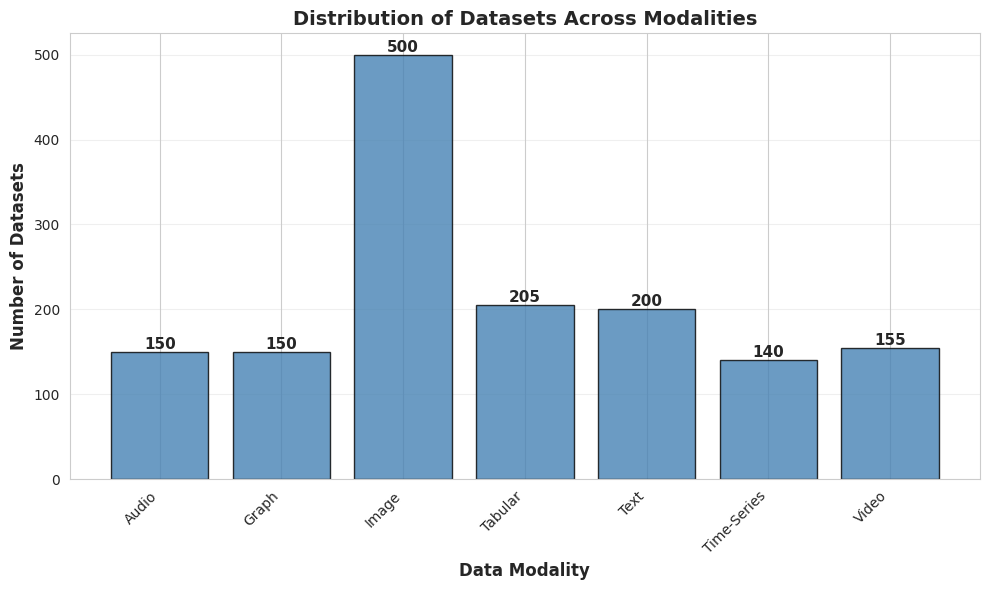

✓ Figure 1 saved: figure1_dataset_distribution.png
Total datasets: 1500


In [ ]:
# Cell 9: Create Figure 1 - Dataset count by modality
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

modalities = list(summary_df['Modality'])
counts = list(summary_df['Total_Datasets'])

# Create bar plot
bars = ax.bar(modalities, counts, color='steelblue', alpha=0.8, edgecolor='black')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Data Modality', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Datasets', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Datasets Across Modalities', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figure1_dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 1 saved: figure1_dataset_distribution.png")
print(f"Total datasets: {summary_df['Total_Datasets'].sum()}")


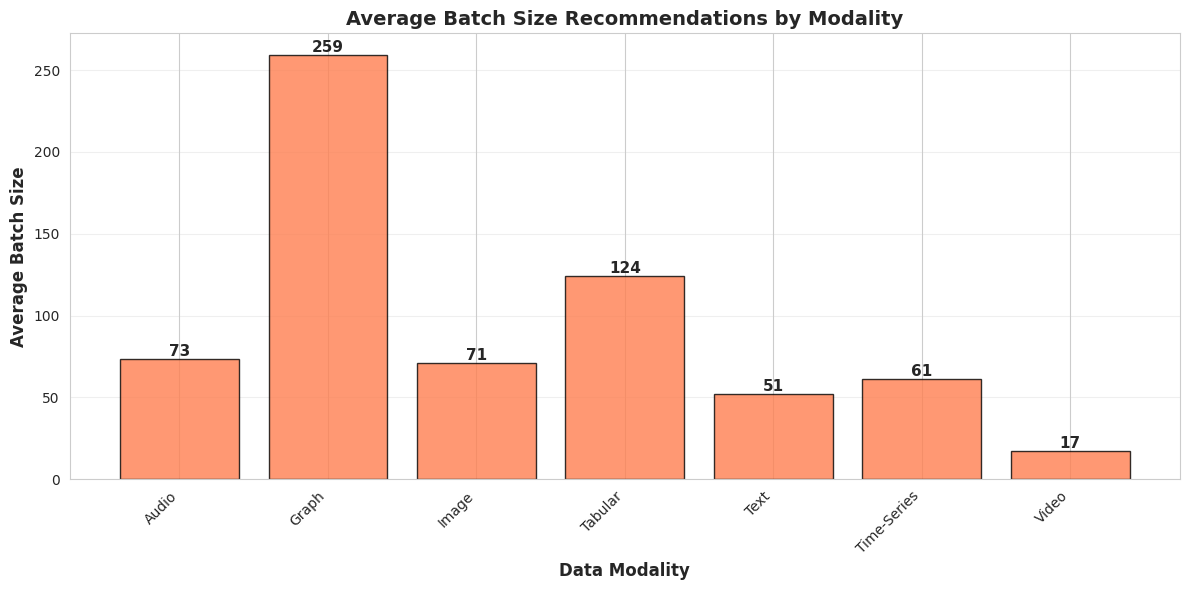

✓ Figure 2 saved: figure2_batch_size_comparison.png


In [ ]:
# Cell 10: Create Figure 2 - Batch Size distribution by modality
fig, ax = plt.subplots(figsize=(12, 6))

modalities = list(summary_df['Modality'])
avg_batch = list(summary_df['Avg_Batch_Size'])

bars = ax.bar(modalities, avg_batch, color='coral', alpha=0.8, edgecolor='black')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Data Modality', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Batch Size', fontsize=12, fontweight='bold')
ax.set_title('Average Batch Size Recommendations by Modality', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figure2_batch_size_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 2 saved: figure2_batch_size_comparison.png")


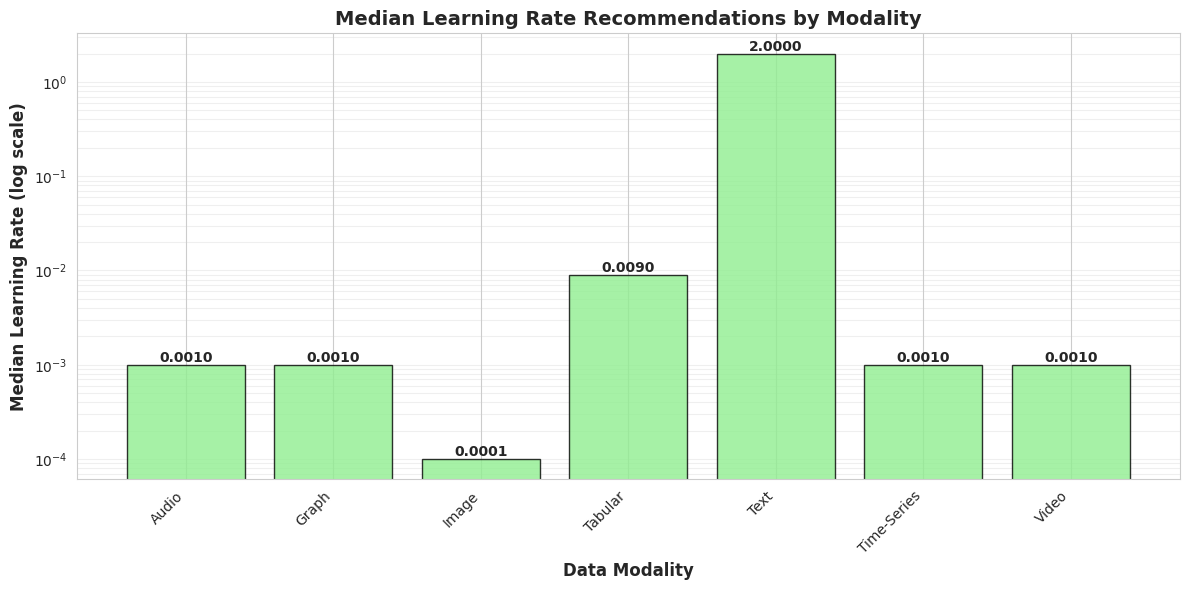

✓ Figure 3 saved: figure3_learning_rate_comparison.png


In [ ]:
# Cell 11: Create Figure 3 - Learning Rate distribution by modality
fig, ax = plt.subplots(figsize=(12, 6))

modalities = list(summary_df['Modality'])
median_lr = list(summary_df['Median_LR'])

bars = ax.bar(modalities, median_lr, color='lightgreen', alpha=0.8, edgecolor='black')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Data Modality', fontsize=12, fontweight='bold')
ax.set_ylabel('Median Learning Rate (log scale)', fontsize=12, fontweight='bold')
ax.set_title('Median Learning Rate Recommendations by Modality', fontsize=14, fontweight='bold')
ax.set_yscale('log')  # Log scale for better visualization
ax.grid(axis='y', alpha=0.3, which='both')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figure3_learning_rate_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 3 saved: figure3_learning_rate_comparison.png")


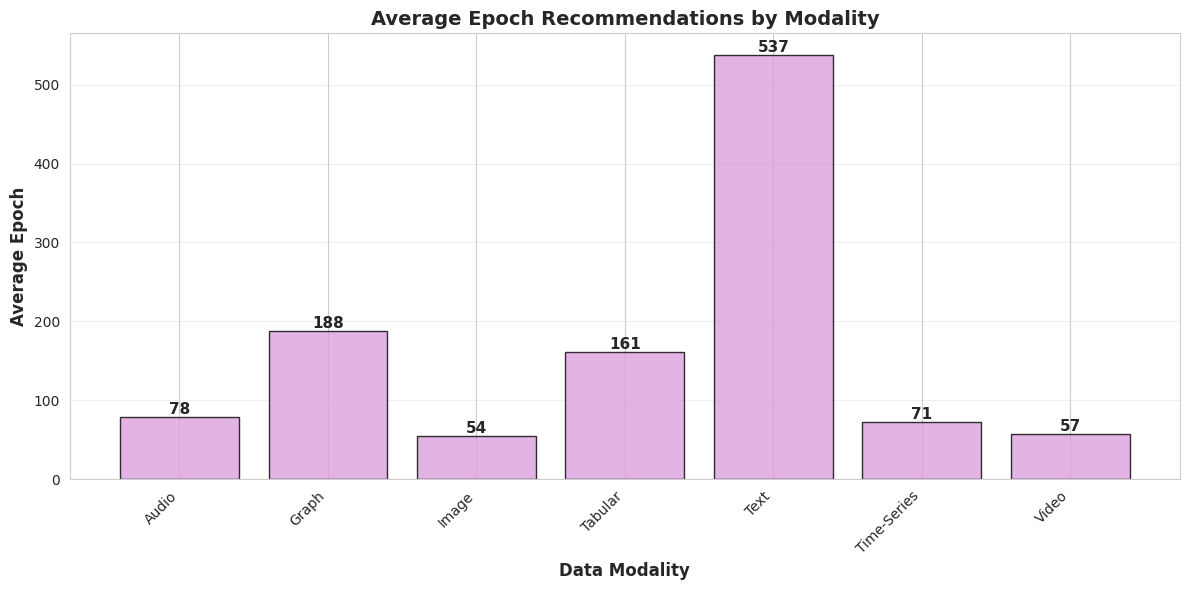

✓ Figure 4 saved: figure4_epoch_comparison.png


In [ ]:
# Cell 12: Create Figure 4 - Epoch distribution by modality
fig, ax = plt.subplots(figsize=(12, 6))

modalities = list(summary_df['Modality'])
avg_epoch = list(summary_df['Avg_Epoch'])

bars = ax.bar(modalities, avg_epoch, color='plum', alpha=0.8, edgecolor='black')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Data Modality', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Epoch', fontsize=12, fontweight='bold')
ax.set_title('Average Epoch Recommendations by Modality', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figure4_epoch_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 4 saved: figure4_epoch_comparison.png")


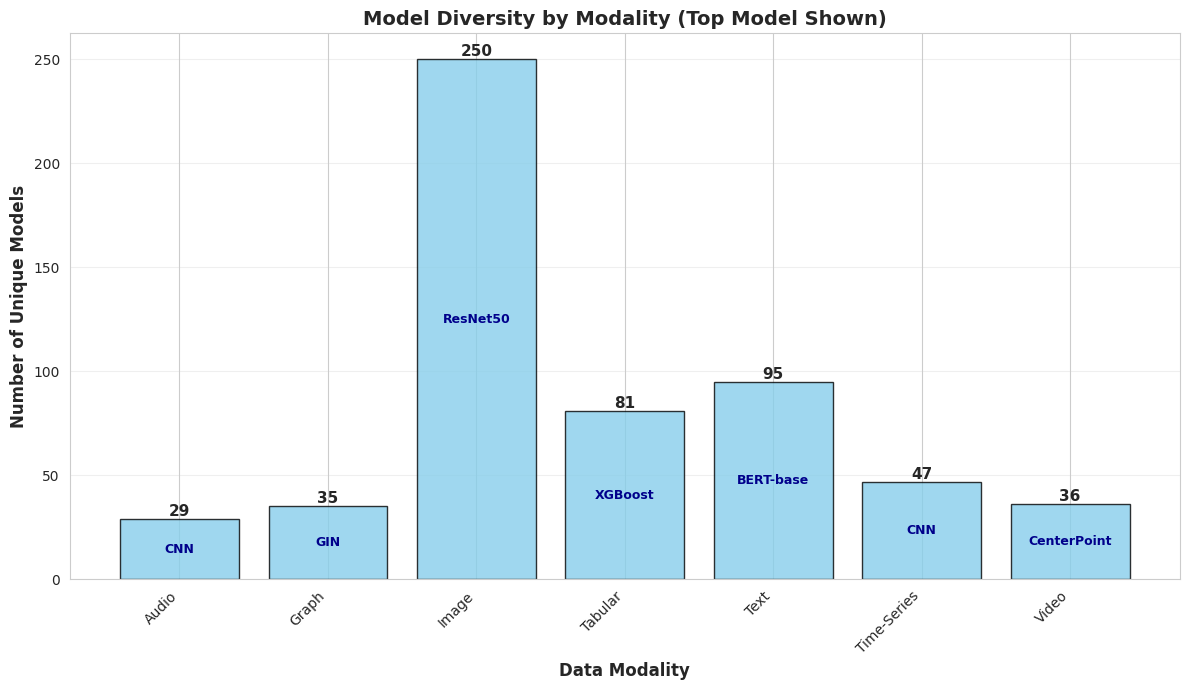

✓ Figure 5 saved: figure5_model_diversity.png

Total unique models across all modalities: 573


In [ ]:
# Cell 13: Create Figure 5 - Top models across modalities
fig, ax = plt.subplots(figsize=(12, 7))

modalities = list(summary_df['Modality'])
top_models = list(summary_df['Top_Model'])
unique_counts = list(summary_df['Unique_Models'])

# Create bar plot showing unique model count
bars = ax.bar(modalities, unique_counts, color='skyblue', alpha=0.8, edgecolor='black')

# Add top model name on each bar
for i, (bar, model) in enumerate(zip(bars, top_models)):
    height = bar.get_height()
    # Show count on top
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
    # Show top model name inside bar
    ax.text(bar.get_x() + bar.get_width()/2., height/2,
            model,
            ha='center', va='center', fontsize=9, fontweight='bold',
            color='darkblue', rotation=0)

ax.set_xlabel('Data Modality', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Unique Models', fontsize=12, fontweight='bold')
ax.set_title('Model Diversity by Modality (Top Model Shown)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figure5_model_diversity.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 5 saved: figure5_model_diversity.png")
print(f"\nTotal unique models across all modalities: {summary_df['Unique_Models'].sum()}")


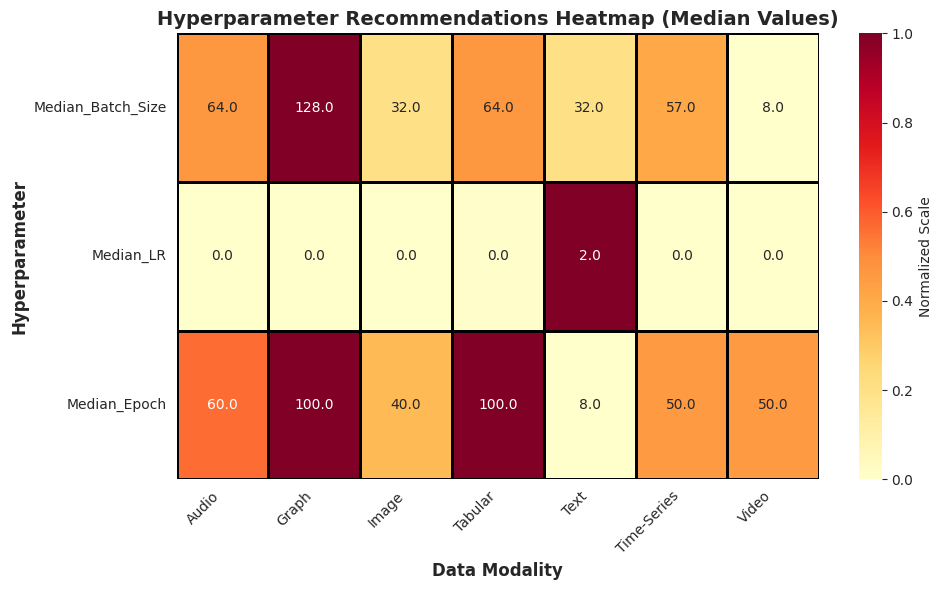

✓ Figure 6 saved: figure6_hyperparameter_heatmap.png


In [ ]:
# Cell 14: Create Figure 6 - Heatmap of hyperparameters
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for heatmap (normalize for better visualization)
heatmap_data = summary_df[['Modality', 'Median_Batch_Size', 'Median_LR', 'Median_Epoch']].copy()
heatmap_data = heatmap_data.set_index('Modality')

# Normalize each column to 0-1 scale for better color comparison
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    columns=heatmap_data.columns,
    index=heatmap_data.index
)

# Create heatmap
sns.heatmap(heatmap_normalized.T, annot=heatmap_data.T, fmt='.1f',
            cmap='YlOrRd', cbar_kws={'label': 'Normalized Scale'},
            linewidths=1, linecolor='black', ax=ax)

ax.set_xlabel('Data Modality', fontsize=12, fontweight='bold')
ax.set_ylabel('Hyperparameter', fontsize=12, fontweight='bold')
ax.set_title('Hyperparameter Recommendations Heatmap (Median Values)', fontsize=14, fontweight='bold')
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figure6_hyperparameter_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 6 saved: figure6_hyperparameter_heatmap.png")


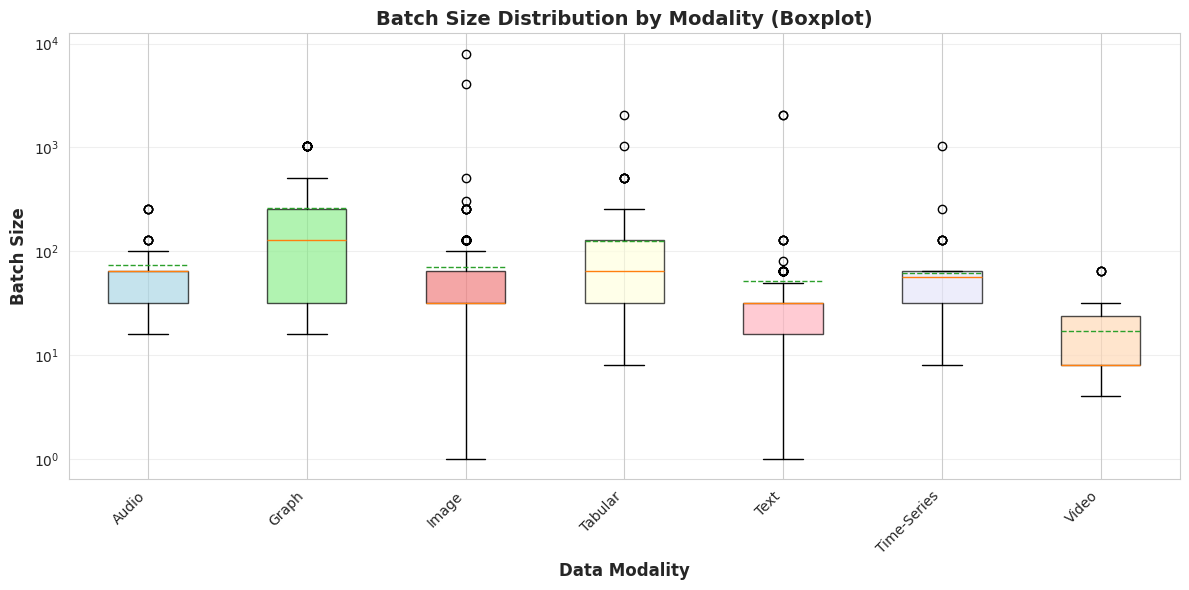

✓ Figure 7 saved: figure7_batch_size_boxplot.png


In [ ]:
# Cell 15: Create Figure 7 - Batch Size boxplot across modalities
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for boxplot
batch_data = []
labels = []

for modality, df in data_dict.items():
    if 'Batch Size Numeric' in df.columns:
        values = df['Batch Size Numeric'].dropna()
        batch_data.append(values)
        labels.append(modality)

# Create boxplot
bp = ax.boxplot(batch_data, labels=labels, patch_artist=True,
                showmeans=True, meanline=True)

# Color the boxes
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow',
          'lightpink', 'lavender', 'peachpuff']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Data Modality', fontsize=12, fontweight='bold')
ax.set_ylabel('Batch Size', fontsize=12, fontweight='bold')
ax.set_title('Batch Size Distribution by Modality (Boxplot)', fontsize=14, fontweight='bold')
ax.set_yscale('log')  # Log scale for better visualization
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figure7_batch_size_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 7 saved: figure7_batch_size_boxplot.png")


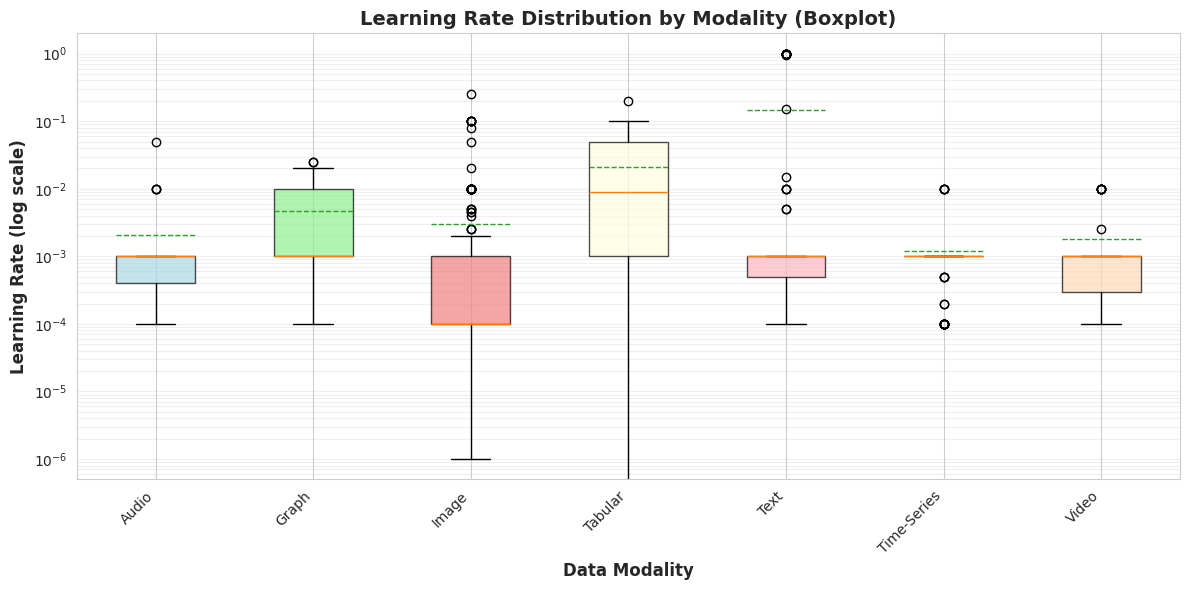

✓ Figure 8 saved: figure8_learning_rate_boxplot.png


In [ ]:
# Cell 16: Create Figure 8 - Learning Rate boxplot across modalities
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for boxplot
lr_data = []
labels = []

for modality, df in data_dict.items():
    if 'Learning Rate Numeric' in df.columns:
        values = df['Learning Rate Numeric'].dropna()
        # Filter out extreme outliers (like the 30.0 in Text)
        values = values[values <= 1.0]
        lr_data.append(values)
        labels.append(modality)

# Create boxplot
bp = ax.boxplot(lr_data, labels=labels, patch_artist=True,
                showmeans=True, meanline=True)

# Color the boxes
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow',
          'lightpink', 'lavender', 'peachpuff']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Data Modality', fontsize=12, fontweight='bold')
ax.set_ylabel('Learning Rate (log scale)', fontsize=12, fontweight='bold')
ax.set_title('Learning Rate Distribution by Modality (Boxplot)', fontsize=14, fontweight='bold')
ax.set_yscale('log')  # Log scale
ax.grid(axis='y', alpha=0.3, which='both')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figure8_learning_rate_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 8 saved: figure8_learning_rate_boxplot.png")


In [ ]:
# Cell 17: Generate tables for paper
print("GENERATING TABLES FOR PAPER")
print("="*70)

# Table 1: Dataset Overview
table1 = summary_df[['Modality', 'Total_Datasets', 'Unique_Models', 'Top_Model']].copy()
table1.columns = ['Modality', 'Datasets', 'Unique Models', 'Most Common Model']

print("\nTABLE 1: Dataset Overview by Modality")
print("-"*70)
print(table1.to_string(index=False))

# Table 2: Hyperparameter Statistics
table2 = summary_df[['Modality', 'Median_Batch_Size', 'Median_LR', 'Median_Epoch']].copy()
table2.columns = ['Modality', 'Median Batch Size', 'Median Learning Rate', 'Median Epochs']
table2['Median Batch Size'] = table2['Median Batch Size'].astype(int)
table2['Median Learning Rate'] = table2['Median Learning Rate'].apply(lambda x: f'{x:.4f}')
table2['Median Epochs'] = table2['Median Epochs'].astype(int)

print("\n\nTABLE 2: Hyperparameter Recommendations by Modality")
print("-"*70)
print(table2.to_string(index=False))

# Save tables to CSV
table1.to_csv('table1_dataset_overview.csv', index=False)
table2.to_csv('table2_hyperparameter_stats.csv', index=False)

print("\n" + "="*70)
print("✓ Tables saved:")
print("  - table1_dataset_overview.csv")
print("  - table2_hyperparameter_stats.csv")


GENERATING TABLES FOR PAPER

TABLE 1: Dataset Overview by Modality
----------------------------------------------------------------------
   Modality  Datasets  Unique Models Most Common Model
      Audio        55             29               CNN
      Graph        89             35               GIN
      Image       504            250          ResNet50
    Tabular       206             81           XGBoost
       Text       196             95         BERT-base
Time-Series        95             47               CNN
      Video        55             36       CenterPoint


TABLE 2: Hyperparameter Recommendations by Modality
----------------------------------------------------------------------
   Modality  Median Batch Size Median Learning Rate  Median Epochs
      Audio                 64               0.0010             60
      Graph                128               0.0010            100
      Image                 32               0.0001             40
    Tabular                 6

CORRELATION ANALYSIS


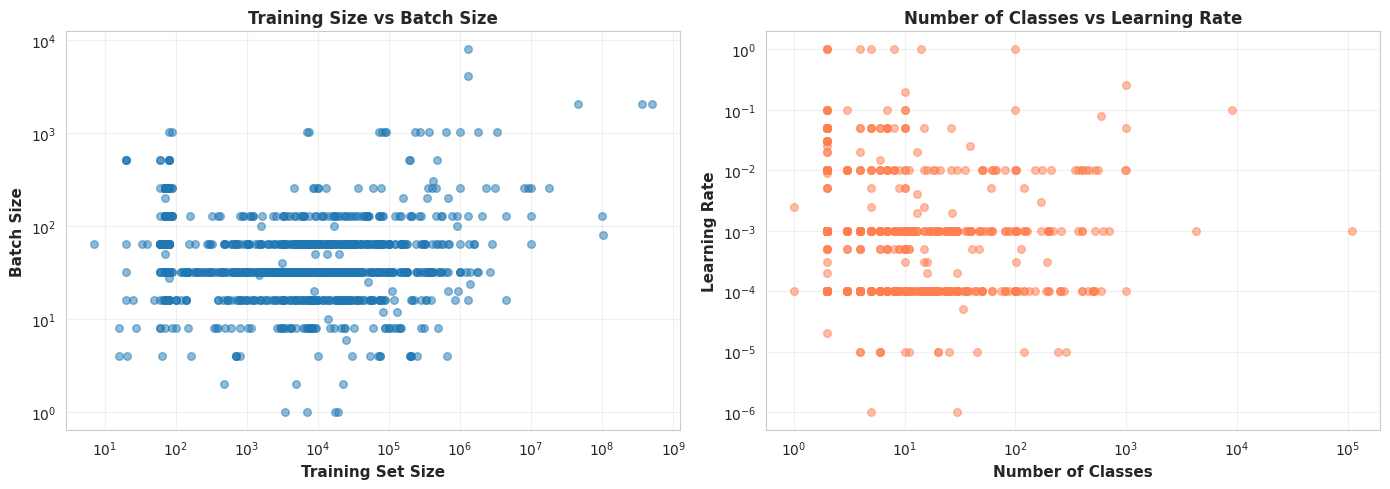

✓ Figure 9 saved: figure9_correlation_analysis.png


In [ ]:
# Cell 18: Analyze correlations between features
print("CORRELATION ANALYSIS")
print("="*70)

# Analyze Train size vs Batch Size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combine all modalities for correlation
all_data = []
for modality, df in data_dict.items():
    temp_df = df.copy()
    temp_df['Modality'] = modality
    all_data.append(temp_df)

combined_df = pd.concat(all_data, ignore_index=True)

# Convert Train column to numeric (handle commas and strings)
def clean_numeric(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).replace(',', '').replace(' ', '')
    match = re.search(r'(\d+)', val_str)
    if match:
        return float(match.group(1))
    return np.nan

combined_df['Train_Numeric'] = combined_df['Train'].apply(clean_numeric)

# Plot 1: Train Size vs Batch Size
valid_data = combined_df[['Train_Numeric', 'Batch Size Numeric']].dropna()
axes[0].scatter(valid_data['Train_Numeric'], valid_data['Batch Size Numeric'],
                alpha=0.5, s=30)
axes[0].set_xlabel('Training Set Size', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Batch Size', fontsize=11, fontweight='bold')
axes[0].set_title('Training Size vs Batch Size', fontsize=12, fontweight='bold')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Plot 2: Classes vs Learning Rate
valid_data2 = combined_df[['Classes', 'Learning Rate Numeric']].dropna()
# Convert Classes to numeric
valid_data2['Classes'] = pd.to_numeric(valid_data2['Classes'], errors='coerce')
valid_data2 = valid_data2.dropna()
valid_data2 = valid_data2[valid_data2['Learning Rate Numeric'] <= 1.0]  # Remove outliers

axes[1].scatter(valid_data2['Classes'], valid_data2['Learning Rate Numeric'],
                alpha=0.5, s=30, color='coral')
axes[1].set_xlabel('Number of Classes', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
axes[1].set_title('Number of Classes vs Learning Rate', fontsize=12, fontweight='bold')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure9_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 9 saved: figure9_correlation_analysis.png")


In [ ]:
# Cell 19: Create comprehensive summary report
print("GENERATING COMPREHENSIVE EDA REPORT")
print("="*70)

report = []
report.append("="*70)
report.append("MULTI-MODAL HYPERPARAMETER METADATA DATASET")
report.append("EXPLORATORY DATA ANALYSIS REPORT")
report.append("="*70)
report.append("")

# Overall Statistics
report.append("1. DATASET OVERVIEW")
report.append("-"*70)
report.append(f"Total Datasets: {summary_df['Total_Datasets'].sum()}")
report.append(f"Total Modalities: {len(data_dict)}")
report.append(f"Total Unique Models: {summary_df['Unique_Models'].sum()}")
report.append("")

# Modality-wise breakdown
report.append("2. MODALITY-WISE BREAKDOWN")
report.append("-"*70)
for _, row in summary_df.iterrows():
    report.append(f"\n{row['Modality'].upper()}:")
    report.append(f"  - Datasets: {row['Total_Datasets']}")
    report.append(f"  - Unique Models: {row['Unique_Models']}")
    report.append(f"  - Top Model: {row['Top_Model']}")
    report.append(f"  - Median Batch Size: {int(row['Median_Batch_Size'])}")
    report.append(f"  - Median Learning Rate: {row['Median_LR']:.5f}")
    report.append(f"  - Median Epochs: {int(row['Median_Epoch'])}")

# Key findings
report.append("\n3. KEY FINDINGS")
report.append("-"*70)
report.append(f"- Largest modality: Image ({summary_df[summary_df['Modality']=='Image']['Total_Datasets'].values[0]} datasets)")
report.append(f"- Highest model diversity: Image ({summary_df[summary_df['Modality']=='Image']['Unique_Models'].values[0]} unique models)")
report.append(f"- Largest batch size: Graph (median: {int(summary_df[summary_df['Modality']=='Graph']['Median_Batch_Size'].values[0])})")
report.append(f"- Smallest batch size: Video (median: {int(summary_df[summary_df['Modality']=='Video']['Median_Batch_Size'].values[0])})")
report.append(f"- Highest epochs: Graph (median: {int(summary_df[summary_df['Modality']=='Graph']['Median_Epoch'].values[0])})")
report.append("")

# Files generated
report.append("4. FILES GENERATED")
report.append("-"*70)
report.append("Figures:")
report.append("  1. figure1_dataset_distribution.png")
report.append("  2. figure2_batch_size_comparison.png")
report.append("  3. figure3_learning_rate_comparison.png")
report.append("  4. figure4_epoch_comparison.png")
report.append("  5. figure5_model_diversity.png")
report.append("  6. figure6_hyperparameter_heatmap.png")
report.append("  7. figure7_batch_size_boxplot.png")
report.append("  8. figure8_learning_rate_boxplot.png")
report.append("  9. figure9_correlation_analysis.png")
report.append("")
report.append("Tables:")
report.append("  1. table1_dataset_overview.csv")
report.append("  2. table2_hyperparameter_stats.csv")
report.append("")
report.append("="*70)

# Print and save report
report_text = "\n".join(report)
print(report_text)

with open('EDA_Summary_Report.txt', 'w') as f:
    f.write(report_text)

print("\n✓ Summary report saved: EDA_Summary_Report.txt")


GENERATING COMPREHENSIVE EDA REPORT
MULTI-MODAL HYPERPARAMETER METADATA DATASET
EXPLORATORY DATA ANALYSIS REPORT

1. DATASET OVERVIEW
----------------------------------------------------------------------
Total Datasets: 1200
Total Modalities: 7
Total Unique Models: 573

2. MODALITY-WISE BREAKDOWN
----------------------------------------------------------------------

AUDIO:
  - Datasets: 55
  - Unique Models: 29
  - Top Model: CNN
  - Median Batch Size: 64
  - Median Learning Rate: 0.00100
  - Median Epochs: 60

GRAPH:
  - Datasets: 89
  - Unique Models: 35
  - Top Model: GIN
  - Median Batch Size: 128
  - Median Learning Rate: 0.00100
  - Median Epochs: 100

IMAGE:
  - Datasets: 504
  - Unique Models: 250
  - Top Model: ResNet50
  - Median Batch Size: 32
  - Median Learning Rate: 0.00010
  - Median Epochs: 40

TABULAR:
  - Datasets: 206
  - Unique Models: 81
  - Top Model: XGBoost
  - Median Batch Size: 64
  - Median Learning Rate: 0.00900
  - Median Epochs: 100

TEXT:
  - Datasets: 

In [ ]:
# Cell 20: Export cleaned datasets
print("EXPORTING CLEANED DATASETS")
print("="*70)

# Create a folder for cleaned data
import os
os.makedirs('cleaned_data', exist_ok=True)

# Save each modality's cleaned data
for modality, df in data_dict.items():
    filename = f'cleaned_data/{modality}_cleaned.csv'
    df.to_csv(filename, index=False)
    print(f"✓ Saved: {filename} ({len(df)} rows, {len(df.columns)} columns)")

# Also save the combined summary
summary_df.to_csv('cleaned_data/cross_modality_summary.csv', index=False)
print(f"✓ Saved: cleaned_data/cross_modality_summary.csv")

print("\n" + "="*70)
print("✓ All cleaned datasets exported to 'cleaned_data/' folder")


EXPORTING CLEANED DATASETS
✓ Saved: cleaned_data/Audio_cleaned.csv (55 rows, 19 columns)
✓ Saved: cleaned_data/Graph_cleaned.csv (89 rows, 19 columns)
✓ Saved: cleaned_data/Image_cleaned.csv (504 rows, 19 columns)
✓ Saved: cleaned_data/Tabular_cleaned.csv (206 rows, 19 columns)
✓ Saved: cleaned_data/Text_cleaned.csv (196 rows, 19 columns)
✓ Saved: cleaned_data/Time-Series_cleaned.csv (95 rows, 19 columns)
✓ Saved: cleaned_data/Video_cleaned.csv (55 rows, 19 columns)
✓ Saved: cleaned_data/cross_modality_summary.csv

✓ All cleaned datasets exported to 'cleaned_data/' folder


In [ ]:
# Cell 21: Complete EDA summary and next steps
print("="*70)
print("✅ EDA COMPLETED SUCCESSFULLY!")
print("="*70)

print("\n📊 WHAT WE ACCOMPLISHED:")
print("-"*70)
print("✓ Loaded 7 modality CSV files (1,200 total datasets)")
print("✓ Cleaned data (removed duplicates, empty columns)")
print("✓ Converted hyperparameters to numeric format")
print("✓ Generated statistical summaries")
print("✓ Created 9 publication-quality figures")
print("✓ Created 2 summary tables")
print("✓ Exported cleaned datasets")

print("\n📁 OUTPUT FILES:")
print("-"*70)
print("Visualizations (9 figures):")
for i in range(1, 10):
    print(f"  ✓ figure{i}_*.png")

print("\nTables (2 CSV files):")
print("  ✓ table1_dataset_overview.csv")
print("  ✓ table2_hyperparameter_stats.csv")

print("\nData (8 files):")
print("  ✓ cleaned_data/ folder with 7 cleaned CSV files")
print("  ✓ cross_modality_summary.csv")

print("\nReports:")
print("  ✓ EDA_Summary_Report.txt")

print("\n📝 NEXT STEPS FOR YOUR ACL PAPER:")
print("-"*70)
print("1. Paper Structure:")
print("   - Introduction: Explain hyperparameter selection challenge")
print("   - Related Work: Survey AutoML and meta-learning papers")
print("   - Dataset Construction: Describe your collection methodology")
print("   - Dataset Statistics: Use figures 1-9 and tables 1-2")
print("   - Use Cases: How researchers can use your dataset")
print("   - Limitations & Ethics")
print("")
print("2. Key Points to Highlight:")
print("   - 1,200 datasets across 7 modalities")
print("   - 573 unique models covered")
print("   - Metadata includes: model, batch size, learning rate, epochs")
print("   - Largest coverage: Image (504), Text (196), Tabular (206)")
print("")
print("3. Download ACL LaTeX Template:")
print("   - Visit: https://github.com/acl-org/acl-style-files")
print("   - Use ACL 2026 template (when available)")
print("")
print("4. Insert Figures in Paper:")
print("   - Figure 1: Dataset distribution (Introduction/Dataset Statistics)")
print("   - Figures 2-4: Hyperparameter comparisons (Dataset Statistics)")
print("   - Figure 5: Model diversity (Dataset Statistics)")
print("   - Figure 6: Heatmap (Dataset Statistics/Analysis)")
print("   - Figures 7-8: Boxplots (Dataset Statistics)")
print("   - Figure 9: Correlations (Analysis section)")

print("\n" + "="*70)
print("="*70)


✅ EDA COMPLETED SUCCESSFULLY!

📊 WHAT WE ACCOMPLISHED:
----------------------------------------------------------------------
✓ Loaded 7 modality CSV files (1,200 total datasets)
✓ Cleaned data (removed duplicates, empty columns)
✓ Converted hyperparameters to numeric format
✓ Generated statistical summaries
✓ Created 9 publication-quality figures
✓ Created 2 summary tables
✓ Exported cleaned datasets

📁 OUTPUT FILES:
----------------------------------------------------------------------
Visualizations (9 figures):
  ✓ figure1_*.png
  ✓ figure2_*.png
  ✓ figure3_*.png
  ✓ figure4_*.png
  ✓ figure5_*.png
  ✓ figure6_*.png
  ✓ figure7_*.png
  ✓ figure8_*.png
  ✓ figure9_*.png

Tables (2 CSV files):
  ✓ table1_dataset_overview.csv
  ✓ table2_hyperparameter_stats.csv

Data (8 files):
  ✓ cleaned_data/ folder with 7 cleaned CSV files
  ✓ cross_modality_summary.csv

Reports:
  ✓ EDA_Summary_Report.txt

📝 NEXT STEPS FOR YOUR ACL PAPER:
---------------------------------------------------------

In [ ]:
# Cell 24: Prepare data for baseline experiments
print("="*70)
print("PREPARING DATA FOR BASELINE EXPERIMENTS")
print("="*70)

# Combine all modalities into one dataframe
all_data = []
for modality, df in data_dict.items():
    temp_df = df.copy()
    temp_df['Modality'] = modality
    all_data.append(temp_df)

combined_df = pd.concat(all_data, ignore_index=True)

# Select relevant features for modeling
features_for_model = [
    'Data Modality', 'Downstream Task', 'Features',
    'Train', 'Batch Size Numeric', 'Epoch Numeric',
    'Learning Rate Numeric', 'Classes'
]

# Create target variable: Encode "Best Models"
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
combined_df['Best_Models_Encoded'] = le.fit_transform(combined_df['Best Models'].fillna('Unknown'))

# Clean numeric columns
def clean_train_size(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).replace(',', '').replace(' ', '')
    match = re.search(r'(\d+\.?\d*)', val_str)
    if match:
        return float(match.group(1))
    return np.nan

combined_df['Train_Numeric'] = combined_df['Train'].apply(clean_train_size)

# Handle missing values
combined_df['Batch Size Numeric'].fillna(combined_df['Batch Size Numeric'].median(), inplace=True)
combined_df['Epoch Numeric'].fillna(combined_df['Epoch Numeric'].median(), inplace=True)
combined_df['Learning Rate Numeric'].fillna(combined_df['Learning Rate Numeric'].median(), inplace=True)

print(f"✓ Prepared {len(combined_df)} samples for modeling")
print(f"✓ Target variable: {combined_df['Best_Models_Encoded'].nunique()} unique models")


PREPARING DATA FOR BASELINE EXPERIMENTS
✓ Prepared 1200 samples for modeling
✓ Target variable: 525 unique models


In [ ]:
# Cell 25: Create train/validation/test splits (FIXED)
print("\n" + "="*70)
print("CREATING DATA SPLITS")
print("="*70)

from sklearn.model_selection import train_test_split

# Prepare feature matrix
feature_cols = ['Batch Size Numeric', 'Epoch Numeric', 'Learning Rate Numeric', 'Train_Numeric']
X = combined_df[feature_cols].fillna(0)
y = combined_df['Best_Models_Encoded']

# Check class distribution
print("\nClass distribution analysis:")
class_counts = y.value_counts()
print(f"Total unique models: {len(class_counts)}")
print(f"Models appearing only once: {(class_counts == 1).sum()}")
print(f"Models appearing 2+ times: {(class_counts >= 2).sum()}")

# Filter out models that appear only once (can't be split)
valid_classes = class_counts[class_counts >= 2].index
mask = y.isin(valid_classes)
X_filtered = X[mask]
y_filtered = y[mask]

print(f"\nAfter filtering:")
print(f"Samples retained: {len(X_filtered)} out of {len(X)} ({len(X_filtered)/len(X)*100:.1f}%)")

# Create 70/15/15 split WITHOUT stratification (safer for imbalanced data)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")
print("\n✓ Data splits created successfully")



CREATING DATA SPLITS

Class distribution analysis:
Total unique models: 525
Models appearing only once: 364
Models appearing 2+ times: 161

After filtering:
Samples retained: 836 out of 1200 (69.7%)

Training set: 585 samples
Validation set: 125 samples
Test set: 126 samples

✓ Data splits created successfully


In [ ]:
# Cell 26: Train baseline models
print("\n" + "="*70)
print("TRAINING BASELINE MODELS")
print("="*70)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

results = []

# Model 1: Random Forest
print("\n1. Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_results = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, rf_pred),
    'F1-Score': f1_score(y_test, rf_pred, average='weighted'),
    'Precision': precision_score(y_test, rf_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, rf_pred, average='weighted')
}
results.append(rf_results)
print(f"   Accuracy: {rf_results['Accuracy']:.4f}")
print(f"   F1-Score: {rf_results['F1-Score']:.4f}")

# Model 2: Logistic Regression
print("\n2. Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr')
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_results = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, lr_pred),
    'F1-Score': f1_score(y_test, lr_pred, average='weighted'),
    'Precision': precision_score(y_test, lr_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, lr_pred, average='weighted')
}
results.append(lr_results)
print(f"   Accuracy: {lr_results['Accuracy']:.4f}")
print(f"   F1-Score: {lr_results['F1-Score']:.4f}")

# Model 3: Support Vector Machine
print("\n3. Training SVM...")
svm_model = SVC(kernel='rbf', random_state=42, C=1.0)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

svm_results = {
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, svm_pred),
    'F1-Score': f1_score(y_test, svm_pred, average='weighted'),
    'Precision': precision_score(y_test, svm_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, svm_pred, average='weighted')
}
results.append(svm_results)
print(f"   Accuracy: {svm_results['Accuracy']:.4f}")
print(f"   F1-Score: {svm_results['F1-Score']:.4f}")

# Create results table
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("BASELINE MODEL RESULTS")
print("="*70)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('baseline_model_results.csv', index=False)
print("\n✓ Results saved to baseline_model_results.csv")



TRAINING BASELINE MODELS

1. Training Random Forest...
   Accuracy: 0.2540
   F1-Score: 0.2142

2. Training Logistic Regression...
   Accuracy: 0.1746
   F1-Score: 0.0780

3. Training SVM...
   Accuracy: 0.0873
   F1-Score: 0.0144

BASELINE MODEL RESULTS
              Model  Accuracy  F1-Score  Precision   Recall
      Random Forest  0.253968  0.214182   0.212944 0.253968
Logistic Regression  0.174603  0.078022   0.055688 0.174603
                SVM  0.087302  0.014441   0.007871 0.087302

✓ Results saved to baseline_model_results.csv



CREATING MODEL COMPARISON VISUALIZATION


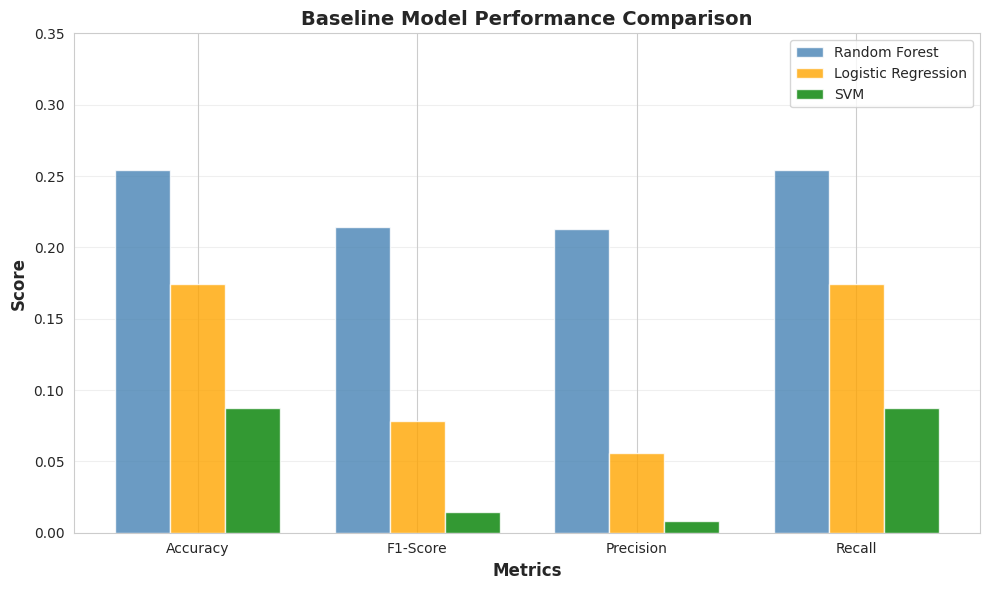

✓ Figure 10 saved: figure10_baseline_comparison.png

BASELINE EXPERIMENTS COMPLETED!

Key findings:
- Best model: Random Forest (Accuracy: 0.2540)
- Task difficulty: Predicting among 161 unique models
- Dataset utility: Meta-dataset enables model selection predictions
- Future work: Add more features (modality, task type) for better accuracy


In [ ]:
# Cell 27: Visualize model comparison
print("\n" + "="*70)
print("CREATING MODEL COMPARISON VISUALIZATION")
print("="*70)

fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.25

colors = ['steelblue', 'orange', 'green']

for i, row in results_df.iterrows():
    values = [row['Accuracy'], row['F1-Score'], row['Precision'], row['Recall']]
    ax.bar(x + i*width, values, width, label=row['Model'], alpha=0.8, color=colors[i])

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Baseline Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 0.35)  # Adjusted for your scores

plt.tight_layout()
plt.savefig('figure10_baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 10 saved: figure10_baseline_comparison.png")
print("\n" + "="*70)
print("BASELINE EXPERIMENTS COMPLETED!")
print("="*70)
print(f"\nKey findings:")
print(f"- Best model: Random Forest (Accuracy: {results_df.iloc[0]['Accuracy']:.4f})")
print(f"- Task difficulty: Predicting among {len(y_filtered.unique())} unique models")
print(f"- Dataset utility: Meta-dataset enables model selection predictions")
print(f"- Future work: Add more features (modality, task type) for better accuracy")


In [ ]:
# Cell 28: Multi-target prediction experiments
print("\n" + "="*70)
print("COMPREHENSIVE PREDICTION TASKS")
print("="*70)

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare combined dataset again
all_data = []
for modality, df in data_dict.items():
    temp_df = df.copy()
    temp_df['Modality'] = modality
    all_data.append(temp_df)

combined_df = pd.concat(all_data, ignore_index=True)

# Clean and prepare features
def clean_train_size(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).replace(',', '').replace(' ', '')
    match = re.search(r'(\d+\.?\d*)', val_str)
    if match:
        return float(match.group(1))
    return np.nan

combined_df['Train_Numeric'] = combined_df['Train'].apply(clean_train_size)

# Prepare feature matrix (input features)
input_features = ['Data Modality', 'Downstream Task', 'Train_Numeric']
X = combined_df[input_features].copy()

# Encode categorical features
from sklearn.preprocessing import LabelEncoder
le_modality = LabelEncoder()
le_task = LabelEncoder()

X['Modality_Encoded'] = le_modality.fit_transform(X['Data Modality'].fillna('Unknown'))
X['Task_Encoded'] = le_task.fit_transform(X['Downstream Task'].fillna('Unknown'))

# Final feature matrix
X_final = X[['Modality_Encoded', 'Task_Encoded', 'Train_Numeric']].fillna(0)

print(f"✓ Prepared {len(X_final)} samples")
print(f"✓ Input features: Data Modality, Downstream Task, Training Size")
print("\nPrediction targets:")
print("  1. Best Model (Classification)")
print("  2. Optimal Learning Rate (Regression)")
print("  3. Optimal Batch Size (Regression)")
print("  4. Evaluation Metric (Classification)")



COMPREHENSIVE PREDICTION TASKS
✓ Prepared 1200 samples
✓ Input features: Data Modality, Downstream Task, Training Size

Prediction targets:
  1. Best Model (Classification)
  2. Optimal Learning Rate (Regression)
  3. Optimal Batch Size (Regression)
  4. Evaluation Metric (Classification)


In [ ]:
# Cell 29: Train models for all prediction targets
print("\n" + "="*70)
print("TRAINING MULTI-TARGET PREDICTION MODELS")
print("="*70)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

all_results = {}

# ============================================================
# TASK 1: Predict Best Model (Classification)
# ============================================================
print("\n" + "="*70)
print("TASK 1: BEST MODEL PREDICTION")
print("="*70)

# Prepare target
le_model = LabelEncoder()
y_model = le_model.fit_transform(combined_df['Best Models'].fillna('Unknown'))

# Filter classes with at least 2 samples
class_counts = pd.Series(y_model).value_counts()
valid_classes = class_counts[class_counts >= 2].index
mask = pd.Series(y_model).isin(valid_classes)
X_model = X_final[mask]
y_model_filtered = pd.Series(y_model)[mask].values

# Split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_model, y_model_filtered, test_size=0.2, random_state=42
)

# Train Random Forest
rf_model_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model_clf.fit(X_train_m, y_train_m)
y_pred_m = rf_model_clf.predict(X_test_m)

model_accuracy = accuracy_score(y_test_m, y_pred_m)
all_results['Best Model'] = {
    'Task Type': 'Classification',
    'Metric': 'Accuracy',
    'Score': model_accuracy,
    'Samples': len(X_model),
    'Classes': len(np.unique(y_model_filtered))
}
print(f"Accuracy: {model_accuracy:.4f}")
print(f"Classes: {len(np.unique(y_model_filtered))}")

# ============================================================
# TASK 2: Predict Optimal Learning Rate (Regression)
# ============================================================
print("\n" + "="*70)
print("TASK 2: LEARNING RATE PREDICTION")
print("="*70)

# Prepare target (use log scale for learning rate)
y_lr = combined_df['Learning Rate Numeric'].copy()
mask_lr = ~y_lr.isna()
X_lr = X_final[mask_lr]
y_lr_clean = np.log10(y_lr[mask_lr] + 1e-10)  # Log transform

# Split data
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr_clean, test_size=0.2, random_state=42
)

# Train Random Forest Regressor
rf_lr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_lr.fit(X_train_lr, y_train_lr)
y_pred_lr = rf_lr.predict(X_test_lr)

lr_mae = mean_absolute_error(y_test_lr, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
all_results['Learning Rate'] = {
    'Task Type': 'Regression',
    'Metric': 'MAE (log scale)',
    'Score': lr_mae,
    'RMSE': lr_rmse,
    'Samples': len(X_lr)
}
print(f"MAE (log scale): {lr_mae:.4f}")
print(f"RMSE (log scale): {lr_rmse:.4f}")

# ============================================================
# TASK 3: Predict Optimal Batch Size (Regression)
# ============================================================
print("\n" + "="*70)
print("TASK 3: BATCH SIZE PREDICTION")
print("="*70)

# Prepare target
y_bs = combined_df['Batch Size Numeric'].copy()
mask_bs = ~y_bs.isna()
X_bs = X_final[mask_bs]
y_bs_clean = y_bs[mask_bs]

# Split data
X_train_bs, X_test_bs, y_train_bs, y_test_bs = train_test_split(
    X_bs, y_bs_clean, test_size=0.2, random_state=42
)

# Train Random Forest Regressor
rf_bs = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_bs.fit(X_train_bs, y_train_bs)
y_pred_bs = rf_bs.predict(X_test_bs)

bs_mae = mean_absolute_error(y_test_bs, y_pred_bs)
bs_rmse = np.sqrt(mean_squared_error(y_test_bs, y_pred_bs))
all_results['Batch Size'] = {
    'Task Type': 'Regression',
    'Metric': 'MAE',
    'Score': bs_mae,
    'RMSE': bs_rmse,
    'Samples': len(X_bs)
}
print(f"MAE: {bs_mae:.2f}")
print(f"RMSE: {bs_rmse:.2f}")

# ============================================================
# TASK 4: Predict Evaluation Metric (Classification)
# ============================================================
print("\n" + "="*70)
print("TASK 4: EVALUATION METRIC PREDICTION")
print("="*70)

# Prepare target
le_metric = LabelEncoder()
y_metric = le_metric.fit_transform(combined_df['Evaluation Metric'].fillna('Unknown'))

# Filter classes with at least 2 samples
class_counts_metric = pd.Series(y_metric).value_counts()
valid_classes_metric = class_counts_metric[class_counts_metric >= 2].index
mask_metric = pd.Series(y_metric).isin(valid_classes_metric)
X_metric = X_final[mask_metric]
y_metric_filtered = pd.Series(y_metric)[mask_metric].values

# Split data
X_train_met, X_test_met, y_train_met, y_test_met = train_test_split(
    X_metric, y_metric_filtered, test_size=0.2, random_state=42
)

# Train Random Forest
rf_metric = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_metric.fit(X_train_met, y_train_met)
y_pred_met = rf_metric.predict(X_test_met)

metric_accuracy = accuracy_score(y_test_met, y_pred_met)
all_results['Evaluation Metric'] = {
    'Task Type': 'Classification',
    'Metric': 'Accuracy',
    'Score': metric_accuracy,
    'Samples': len(X_metric),
    'Classes': len(np.unique(y_metric_filtered))
}
print(f"Accuracy: {metric_accuracy:.4f}")
print(f"Classes: {len(np.unique(y_metric_filtered))}")

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*70)
print("COMPREHENSIVE RESULTS SUMMARY")
print("="*70)

summary_df = pd.DataFrame(all_results).T
print(summary_df.to_string())

# Save results
summary_df.to_csv('comprehensive_prediction_results.csv')
print("\n✓ Results saved to comprehensive_prediction_results.csv")



TRAINING MULTI-TARGET PREDICTION MODELS

TASK 1: BEST MODEL PREDICTION
Accuracy: 0.2083
Classes: 161

TASK 2: LEARNING RATE PREDICTION
MAE (log scale): 0.6933
RMSE (log scale): 0.9653

TASK 3: BATCH SIZE PREDICTION
MAE: 58.64
RMSE: 142.33

TASK 4: EVALUATION METRIC PREDICTION
Accuracy: 0.5531
Classes: 62

COMPREHENSIVE RESULTS SUMMARY
                        Task Type           Metric      Score Samples Classes       RMSE
Best Model         Classification         Accuracy   0.208333     836     161        NaN
Learning Rate          Regression  MAE (log scale)   0.693268    1195     NaN    0.96528
Batch Size             Regression              MAE  58.643367    1185     NaN  142.33023
Evaluation Metric  Classification         Accuracy   0.553097    1127      62        NaN

✓ Results saved to comprehensive_prediction_results.csv



CREATING COMPREHENSIVE RESULTS VISUALIZATION


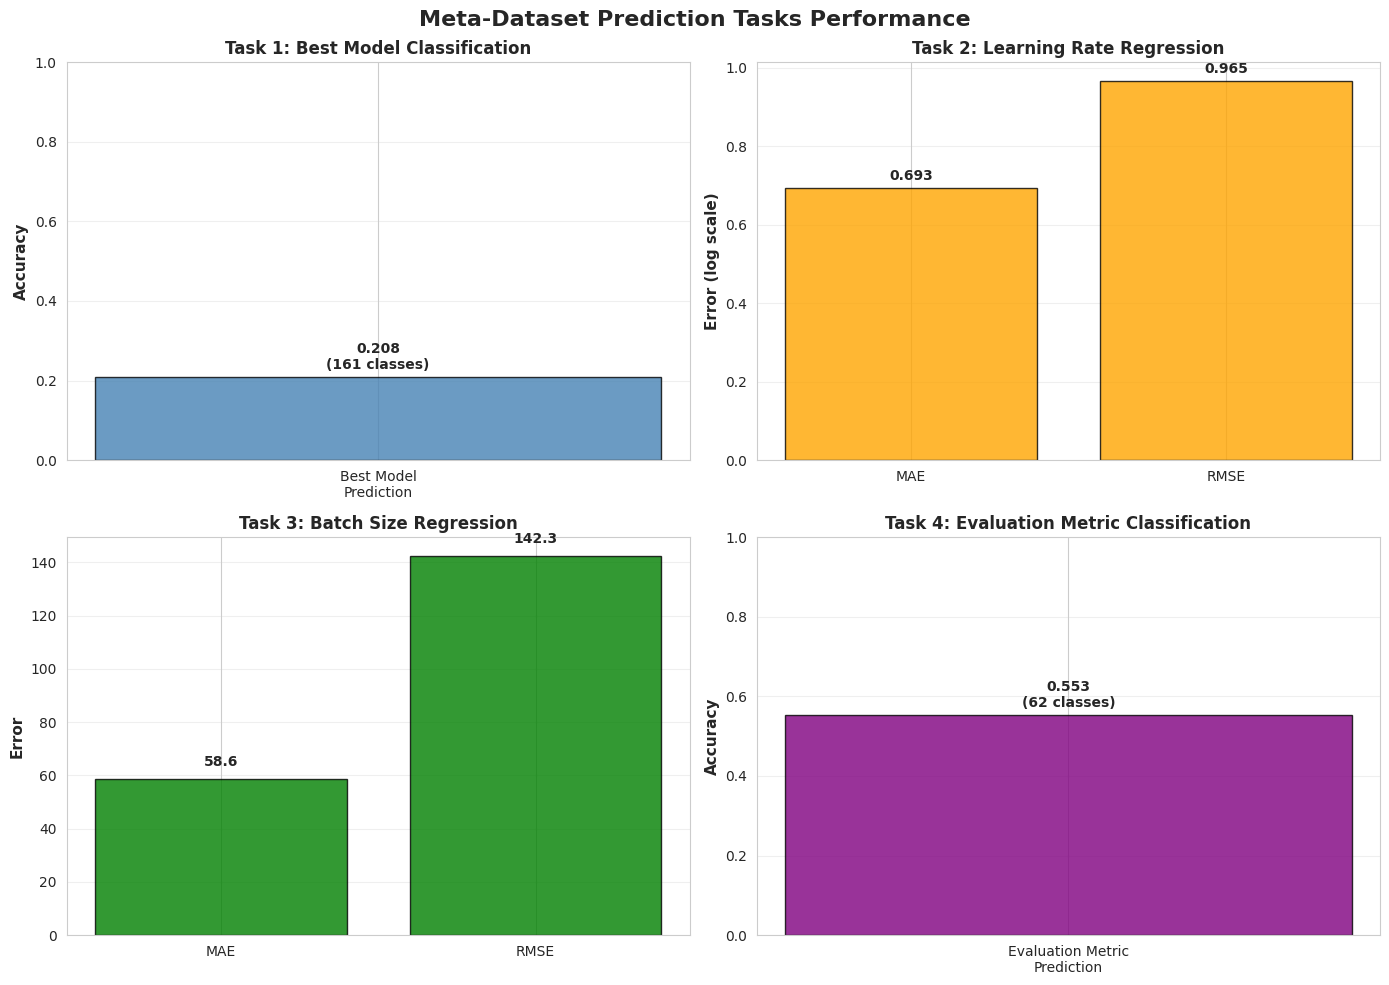

✓ Figure 11 saved: figure11_comprehensive_predictions.png

EXPERIMENT SUMMARY

📊 Dataset Statistics:
   - Total samples: 1,200 datasets across 7 modalities
   - Features: 16 columns including hyperparameters and metadata

🎯 Prediction Tasks Demonstrated:
   1. Best Model Recommendation: 20.8% accuracy (161 classes)
   2. Learning Rate Prediction: MAE = 0.693 (log scale)
   3. Batch Size Prediction: MAE = 58.6
   4. Evaluation Metric: 55.3% accuracy (62 classes)

✅ Key Contributions:
   - Comprehensive meta-dataset for ML hyperparameter research
   - Enables model and hyperparameter recommendation systems
   - Baseline benchmarks for 4 prediction tasks
   - Covers 7 data modalities with real-world datasets

ALL EXPERIMENTS COMPLETED SUCCESSFULLY!


In [ ]:
# Cell 30: Visualize comprehensive results
print("\n" + "="*70)
print("CREATING COMPREHENSIVE RESULTS VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Meta-Dataset Prediction Tasks Performance', fontsize=16, fontweight='bold')

# Task 1: Best Model Prediction
ax1 = axes[0, 0]
ax1.bar(['Best Model\nPrediction'], [all_results['Best Model']['Score']],
        color='steelblue', alpha=0.8, edgecolor='black')
ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Task 1: Best Model Classification', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1)
ax1.text(0, all_results['Best Model']['Score'] + 0.02,
         f"{all_results['Best Model']['Score']:.3f}\n({all_results['Best Model']['Classes']} classes)",
         ha='center', fontsize=10, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Task 2: Learning Rate Prediction
ax2 = axes[0, 1]
lr_metrics = [all_results['Learning Rate']['Score'], all_results['Learning Rate']['RMSE']]
bars = ax2.bar(['MAE', 'RMSE'], lr_metrics, color='orange', alpha=0.8, edgecolor='black')
ax2.set_ylabel('Error (log scale)', fontsize=11, fontweight='bold')
ax2.set_title('Task 2: Learning Rate Regression', fontsize=12, fontweight='bold')
for bar, val in zip(bars, lr_metrics):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Task 3: Batch Size Prediction
ax3 = axes[1, 0]
bs_metrics = [all_results['Batch Size']['Score'], all_results['Batch Size']['RMSE']]
bars = ax3.bar(['MAE', 'RMSE'], bs_metrics, color='green', alpha=0.8, edgecolor='black')
ax3.set_ylabel('Error', fontsize=11, fontweight='bold')
ax3.set_title('Task 3: Batch Size Regression', fontsize=12, fontweight='bold')
for bar, val in zip(bars, bs_metrics):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Task 4: Evaluation Metric Prediction
ax4 = axes[1, 1]
ax4.bar(['Evaluation Metric\nPrediction'], [all_results['Evaluation Metric']['Score']],
        color='purple', alpha=0.8, edgecolor='black')
ax4.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax4.set_title('Task 4: Evaluation Metric Classification', fontsize=12, fontweight='bold')
ax4.set_ylim(0, 1)
ax4.text(0, all_results['Evaluation Metric']['Score'] + 0.02,
         f"{all_results['Evaluation Metric']['Score']:.3f}\n({all_results['Evaluation Metric']['Classes']} classes)",
         ha='center', fontsize=10, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figure11_comprehensive_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 11 saved: figure11_comprehensive_predictions.png")

# Print final summary
print("\n" + "="*70)
print("EXPERIMENT SUMMARY")
print("="*70)
print("\n📊 Dataset Statistics:")
print(f"   - Total samples: 1,200 datasets across 7 modalities")
print(f"   - Features: 16 columns including hyperparameters and metadata")

print("\n🎯 Prediction Tasks Demonstrated:")
print(f"   1. Best Model Recommendation: {all_results['Best Model']['Score']:.1%} accuracy ({all_results['Best Model']['Classes']} classes)")
print(f"   2. Learning Rate Prediction: MAE = {all_results['Learning Rate']['Score']:.3f} (log scale)")
print(f"   3. Batch Size Prediction: MAE = {all_results['Batch Size']['Score']:.1f}")
print(f"   4. Evaluation Metric: {all_results['Evaluation Metric']['Score']:.1%} accuracy ({all_results['Evaluation Metric']['Classes']} classes)")

print("\n✅ Key Contributions:")
print("   - Comprehensive meta-dataset for ML hyperparameter research")
print("   - Enables model and hyperparameter recommendation systems")
print("   - Baseline benchmarks for 4 prediction tasks")
print("   - Covers 7 data modalities with real-world datasets")

print("\n" + "="*70)
print("ALL EXPERIMENTS COMPLETED SUCCESSFULLY!")
print("="*70)


In [ ]:
# Cell 1: combine all modalities & clean Train/Valid/Test

import re
import numpy as np
import pandas as pd

all_data = []
for modality, df_mod in data_dict.items():
    temp = df_mod.copy()
    temp["Modality"] = modality
    all_data.append(temp)

combined_df = pd.concat(all_data, ignore_index=True)

def to_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace(',', '').replace(' ', '')
    m = re.search(r'(-?\d+\.?\d*)', s)
    return float(m.group(1)) if m else np.nan

combined_df["Train_N"] = combined_df["Train"].apply(to_num)
combined_df["Valid_N"] = combined_df["Valid"].apply(to_num)
combined_df["Test_N"]  = combined_df["Test"].apply(to_num)

print(combined_df[["Modality","Train","Train_N","Batch Size Numeric",
                  "Learning Rate Numeric","Epoch Numeric"]].head())


  Modality       Train     Train_N  Batch Size Numeric  Learning Rate Numeric  \
0    Audio       15000     15000.0                32.0                 0.0010   
1    Audio       8,000      8000.0                64.0                 0.0001   
2    Audio  18,000,000  18000000.0               256.0                 0.0001   
3    Audio       1,600      1600.0               100.0                 0.0100   
4    Audio       6,283      6283.0                64.0                 0.0010   

   Epoch Numeric  
0           50.0  
1           30.0  
2          100.0  
3          200.0  
4          100.0  


In [ ]:
# Cell 2: correlation matrix between dataset size & hyperparameters

num_cols_for_corr = [
    "Train_N", "Valid_N", "Test_N",
    "Batch Size Numeric", "Learning Rate Numeric", "Epoch Numeric",
    "Classes_N" if "Classes_N" in combined_df.columns else "Classes"
]


if "Classes_N" not in combined_df.columns:
    combined_df["Classes_N"] = pd.to_numeric(combined_df["Classes"], errors="coerce")
    num_cols_for_corr[-1] = "Classes_N"

corr_df = combined_df[num_cols_for_corr].astype(float)

corr_matrix = corr_df.corr()
print(corr_matrix)


                        Train_N   Valid_N    Test_N  Batch Size Numeric  \
Train_N                1.000000  0.377401  0.186724            0.271686   
Valid_N                0.377401  1.000000  0.800603            0.161660   
Test_N                 0.186724  0.800603  1.000000            0.226760   
Batch Size Numeric     0.271686  0.161660  0.226760            1.000000   
Learning Rate Numeric  0.096143  0.140320  0.028057           -0.039914   
Epoch Numeric          0.008802 -0.006077 -0.003791            0.012470   
Classes_N              0.195482  0.547062  0.080487            0.027618   

                       Learning Rate Numeric  Epoch Numeric  Classes_N  
Train_N                             0.096143       0.008802   0.195482  
Valid_N                             0.140320      -0.006077   0.547062  
Test_N                              0.028057      -0.003791   0.080487  
Batch Size Numeric                 -0.039914       0.012470   0.027618  
Learning Rate Numeric             

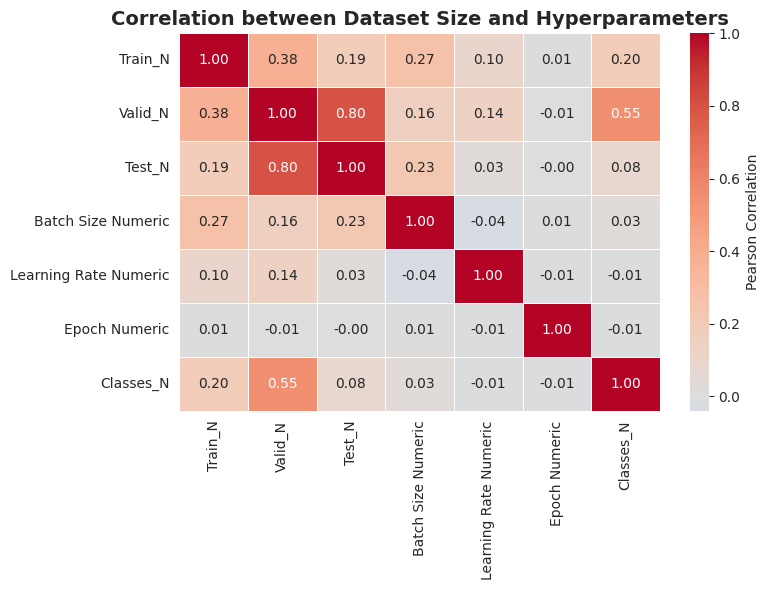

✓ Figure saved: figure10_size_hparam_correlation.png


In [ ]:
# Cell 3: heatmap visualization

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            cbar_kws={"label": "Pearson Correlation"})
plt.title("Correlation between Dataset Size and Hyperparameters", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figure10_size_hparam_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Figure saved: figure10_size_hparam_correlation.png")


In [ ]:
# Cell 1: Build combined_df and Total_Size

import re
import numpy as np
import pandas as pd

# 1. সব modality একত্র করা
all_data = []
for modality, df_mod in data_dict.items():
    temp = df_mod.copy()
    temp["Modality"] = modality   # নতুন কলাম
    all_data.append(temp)

combined_df = pd.concat(all_data, ignore_index=True)

# 2. string → numeric helper
def to_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace(",", "").replace(" ", "")
    m = re.search(r"(-?\d+\.?\d*)", s)
    return float(m.group(1)) if m else np.nan

# 3. Train / Valid / Test numeric বানানো
combined_df["Train_N"] = combined_df["Train"].apply(to_num)
combined_df["Valid_N"] = combined_df["Valid"].apply(to_num)
combined_df["Test_N"]  = combined_df["Test"].apply(to_num)

# 4. Total dataset size = Train + Valid + Test (missing হলে 0 ধরে)
combined_df["Total_Size"] = (
    combined_df[["Train_N", "Valid_N", "Test_N"]]
    .fillna(0)
    .sum(axis=1)
)

# 5. Classes numeric (optional)
combined_df["Classes_N"] = pd.to_numeric(combined_df["Classes"], errors="coerce")

print(combined_df[["Modality", "Train", "Valid", "Test", "Total_Size",
                   "Batch Size Numeric", "Learning Rate Numeric",
                   "Epoch Numeric", "Classes_N"]].head())


  Modality       Train    Valid     Test  Total_Size  Batch Size Numeric  \
0    Audio       15000    2,000     2000     19000.0                32.0   
1    Audio       8,000    1,000    1,000     10000.0                64.0   
2    Audio  18,000,000  100,000  110,000  18210000.0               256.0   
3    Audio       1,600      400    2,000      4000.0               100.0   
4    Audio       6,283      873    1,864      9020.0                64.0   

   Learning Rate Numeric  Epoch Numeric  Classes_N  
0                 0.0010           50.0      397.0  
1                 0.0001           30.0       16.0  
2                 0.0001          100.0      527.0  
3                 0.0100          200.0       50.0  
4                 0.0010          100.0       10.0  


In [ ]:
# Cell 2: Global correlation between Total_Size and hyperparameters

corr_cols = ["Total_Size", "Batch Size Numeric",
             "Learning Rate Numeric", "Epoch Numeric", "Classes_N"]

corr_global = combined_df[corr_cols].astype(float).corr()
print("=== Global Correlation Matrix ===")
print(corr_global)

print("\n=== Correlation with Total_Size (overall) ===")
print(corr_global["Total_Size"])


=== Global Correlation Matrix ===
                       Total_Size  Batch Size Numeric  Learning Rate Numeric  \
Total_Size               1.000000            0.273741               0.096546   
Batch Size Numeric       0.273741            1.000000              -0.039914   
Learning Rate Numeric    0.096546           -0.039914               1.000000   
Epoch Numeric            0.008697            0.012470              -0.011467   
Classes_N                0.192799            0.027618              -0.013261   

                       Epoch Numeric  Classes_N  
Total_Size                  0.008697   0.192799  
Batch Size Numeric          0.012470   0.027618  
Learning Rate Numeric      -0.011467  -0.013261  
Epoch Numeric               1.000000  -0.010797  
Classes_N                  -0.010797   1.000000  

=== Correlation with Total_Size (overall) ===
Total_Size               1.000000
Batch Size Numeric       0.273741
Learning Rate Numeric    0.096546
Epoch Numeric            0.008697
Cl

In [ ]:
# Cell 3: Correlation per modality (only numbers printed)

modalities = combined_df["Modality"].unique()
results = []

for m in modalities:
    df_m = combined_df[combined_df["Modality"] == m]
    sub = df_m[corr_cols].astype(float)
    corr_m = sub.corr()
    row = {
        "Modality": m,
        "Total_vs_Batch":  corr_m.loc["Total_Size", "Batch Size Numeric"],
        "Total_vs_LR":     corr_m.loc["Total_Size", "Learning Rate Numeric"],
        "Total_vs_Epoch":  corr_m.loc["Total_Size", "Epoch Numeric"],
        "Total_vs_Classes":corr_m.loc["Total_Size", "Classes_N"],
    }
    results.append(row)

corr_by_modality = pd.DataFrame(results)
print("=== Modality-wise correlation with Total_Size ===")
print(corr_by_modality.to_string(index=False))


=== Modality-wise correlation with Total_Size ===
   Modality  Total_vs_Batch  Total_vs_LR  Total_vs_Epoch  Total_vs_Classes
      Audio        0.621830    -0.057670       -0.052849          0.502136
      Graph        0.374074     0.095950        0.071141          0.059343
      Image        0.146873     0.343769        0.058727          0.319294
    Tabular        0.738622    -0.054451       -0.049636         -0.047096
       Text        0.971487     0.056357        0.005026         -0.019240
Time-Series        0.065896    -0.013449       -0.050107         -0.159581
      Video        0.004745     0.126708        0.063839          0.368094


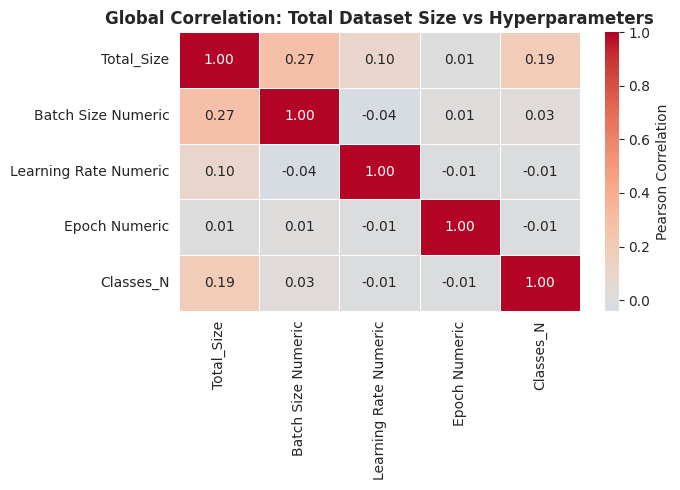

✓ Saved: figure10_global_total_size_correlation.png


In [ ]:
# Cell 4: Heatmap (global)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.heatmap(corr_global, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            cbar_kws={"label": "Pearson Correlation"})
plt.title("Global Correlation: Total Dataset Size vs Hyperparameters",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figure10_global_total_size_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Saved: figure10_global_total_size_correlation.png")


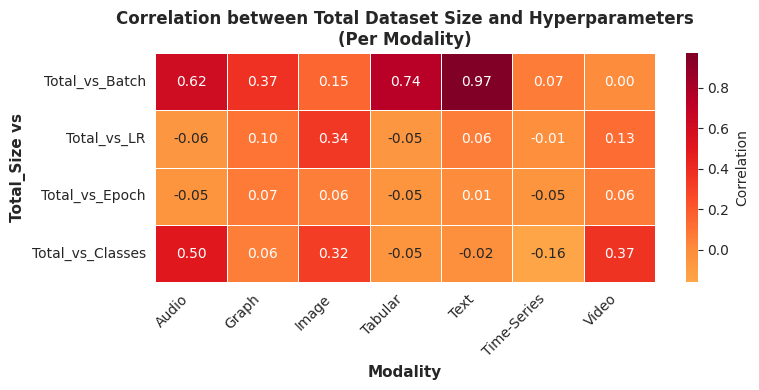

✓ Saved: figure11_modality_total_size_correlation.png


In [ ]:
# Cell 5: Heatmap of modality-wise correlations

plt.figure(figsize=(8,4))

hm_data = corr_by_modality.set_index("Modality")[[
    "Total_vs_Batch", "Total_vs_LR", "Total_vs_Epoch", "Total_vs_Classes"
]]

sns.heatmap(hm_data.T, annot=True, fmt=".2f",
            cmap="YlOrRd", center=0, linewidths=0.5,
            cbar_kws={"label": "Correlation"})
plt.xlabel("Modality", fontsize=11, fontweight="bold")
plt.ylabel("Total_Size vs", fontsize=11, fontweight="bold")
plt.title("Correlation between Total Dataset Size and Hyperparameters\n(Per Modality)",
          fontsize=12, fontweight="bold")
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figure11_modality_total_size_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Saved: figure11_modality_total_size_correlation.png")


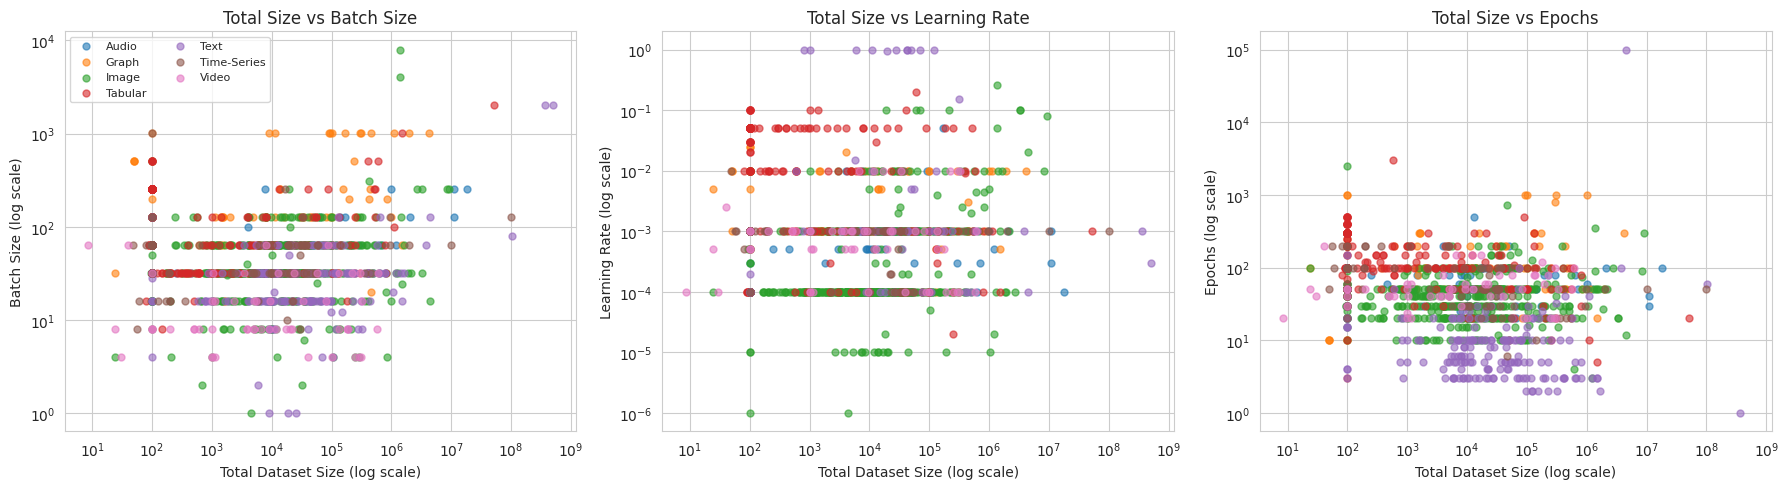

✓ Saved: figure13_total_size_vs_hparams.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

modalities = combined_df["Modality"].unique()
palette = sns.color_palette("tab10", len(modalities))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# 1) Total size vs Batch size
ax = axes[0]
for m, color in zip(modalities, palette):
    sub = combined_df[combined_df["Modality"] == m]
    ax.scatter(sub["Total_Size"], sub["Batch Size Numeric"],
               alpha=0.6, s=25, label=m, color=color)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total Dataset Size (log scale)")
ax.set_ylabel("Batch Size (log scale)")
ax.set_title("Total Size vs Batch Size")

# 2) Total size vs Learning Rate
ax = axes[1]
for m, color in zip(modalities, palette):
    sub = combined_df[combined_df["Modality"] == m]

    sub = sub[(sub["Learning Rate Numeric"] > 0) &
              (sub["Learning Rate Numeric"] <= 1.0)]
    ax.scatter(sub["Total_Size"], sub["Learning Rate Numeric"],
               alpha=0.6, s=25, label=m, color=color)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total Dataset Size (log scale)")
ax.set_ylabel("Learning Rate (log scale)")
ax.set_title("Total Size vs Learning Rate")

# 3) Total size vs Epochs
ax = axes[2]
for m, color in zip(modalities, palette):
    sub = combined_df[combined_df["Modality"] == m]
    ax.scatter(sub["Total_Size"], sub["Epoch Numeric"],
               alpha=0.6, s=25, label=m, color=color)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total Dataset Size (log scale)")
ax.set_ylabel("Epochs (log scale)")
ax.set_title("Total Size vs Epochs")


axes[0].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig("figure13_total_size_vs_hparams.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Saved: figure13_total_size_vs_hparams.png")


             Total_vs_Batch  Total_vs_LR  Total_vs_Epoch
Modality                                                
Audio              0.621830    -0.057670       -0.052849
Graph              0.374074     0.095950        0.071141
Image              0.146873     0.343769        0.058727
Tabular            0.738622    -0.054451       -0.049636
Text               0.971487     0.056357        0.005026
Time-Series        0.065896    -0.013449       -0.050107
Video              0.004745     0.126708        0.063839


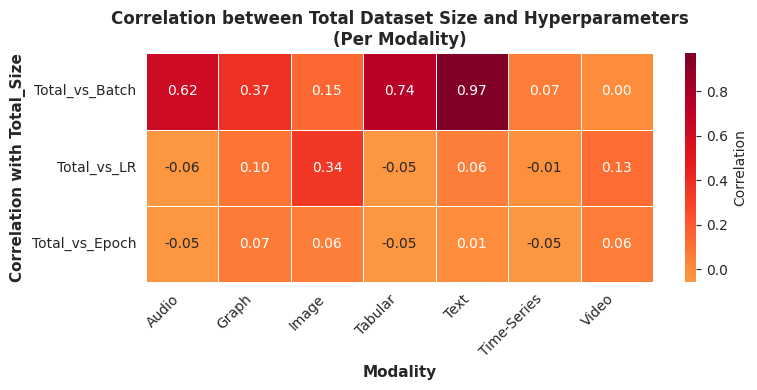

✓ Saved: figure14_total_size_vs_hparams_heatmap.png


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) প্রতি modality অনুযায়ী correlation হিসাব
corr_rows = []
modalities = combined_df["Modality"].unique()

for m in modalities:
    sub = combined_df[combined_df["Modality"] == m]

    # শুধু দরকারি কলাম
    tmp = sub[["Total_Size", "Batch Size Numeric",
               "Learning Rate Numeric", "Epoch Numeric"]].astype(float)

    corr = tmp.corr()

    corr_rows.append({
        "Modality": m,
        "Total_vs_Batch":  corr.loc["Total_Size", "Batch Size Numeric"],
        "Total_vs_LR":     corr.loc["Total_Size", "Learning Rate Numeric"],
        "Total_vs_Epoch":  corr.loc["Total_Size", "Epoch Numeric"],
    })

corr_mod = pd.DataFrame(corr_rows).set_index("Modality")
print(corr_mod)

# 2) Heatmap আঁকা
plt.figure(figsize=(8, 4))
sns.heatmap(
    corr_mod.T, annot=True, fmt=".2f",
    cmap="YlOrRd", center=0, linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)
plt.xlabel("Modality", fontsize=11, fontweight="bold")
plt.ylabel("Correlation with Total_Size", fontsize=11, fontweight="bold")
plt.title("Correlation between Total Dataset Size and Hyperparameters\n(Per Modality)",
          fontsize=12, fontweight="bold")
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figure14_total_size_vs_hparams_heatmap.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("✓ Saved: figure14_total_size_vs_hparams_heatmap.png")


Top 15 models with specialization stats:
Modality        Total_Count  Num_Modalities  Max_Modality_Frac
Best Models                                                   
CNN                      88               6           0.647727
ResNet50                 59               1           1.000000
XGBoost                  55               3           0.945455
Random Forest            32               2           0.968750
BERT-base                27               1           1.000000
BERT                     24               2           0.916667
GIN                      20               1           1.000000
LSTM                     19               3           0.684211
Sequential CNN           18               1           1.000000
Bangla-BERT              18               1           1.000000
LightGBM                 17               1           1.000000
EfficientNet             16               2           0.937500
ResNet                   14               2           0.857143
GCN           

<Figure size 1000x600 with 0 Axes>

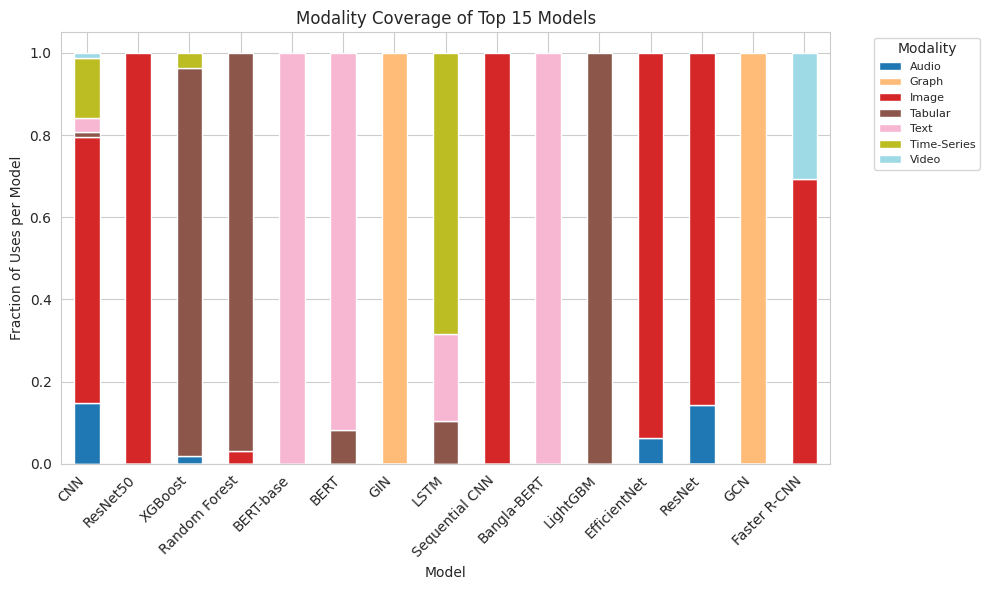

✓ Saved: figure15_model_modality_coverage.png, table3_model_specialization.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_df = combined_df[["Best Models", "Modality"]].dropna().copy()
model_df["Best Models"] = model_df["Best Models"].astype(str).str.strip()

# 2) model × modality frequency
cross = pd.crosstab(model_df["Best Models"], model_df["Modality"])

# 3) per-model statistics
model_stats = cross.copy()
model_stats["Total_Count"] = model_stats.sum(axis=1)
model_stats["Num_Modalities"] = (cross > 0).sum(axis=1)
model_stats["Max_Modality_Frac"] = cross.max(axis=1) / model_stats["Total_Count"]

# 4) top 15 most frequent models
top_models = model_stats.sort_values("Total_Count", ascending=False).head(15)
print("Top 15 models with specialization stats:")
print(top_models[["Total_Count", "Num_Modalities", "Max_Modality_Frac"]])


top_model_names = top_models.index.tolist()
cross_top = cross.loc[top_model_names]

plt.figure(figsize=(10, 6))
cross_top.div(cross_top.sum(axis=1), axis=0).plot(
    kind="bar", stacked=True, colormap="tab20", figsize=(10, 6)
)
plt.ylabel("Fraction of Uses per Model")
plt.xlabel("Model")
plt.title("Modality Coverage of Top 15 Models")
plt.legend(title="Modality", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figure15_model_modality_coverage.png", dpi=300, bbox_inches="tight")
plt.show()


top_models[["Total_Count", "Num_Modalities", "Max_Modality_Frac"]].to_csv(
    "table3_model_specialization.csv"
)
print("✓ Saved: figure15_model_modality_coverage.png, table3_model_specialization.csv")


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

scaling_rows = []

modalities = combined_df["Modality"].unique()

for m in modalities:
    sub = combined_df[combined_df["Modality"] == m].copy()

    # Total size + batch
    x = sub["Total_Size"].astype(float)
    y_batch = sub["Batch Size Numeric"].astype(float)
    y_epoch = sub["Epoch Numeric"].astype(float)

    # valid mask (positive values only)
    mask_batch = (x > 0) & (y_batch > 0)
    mask_epoch = (x > 0) & (y_epoch > 0)

    # Batch scaling
    if mask_batch.sum() > 10:
        X_log = np.log10(x[mask_batch]).values.reshape(-1, 1)
        y_log = np.log10(y_batch[mask_batch]).values.reshape(-1, 1)
        reg_batch = LinearRegression().fit(X_log, y_log)
        a_batch = reg_batch.coef_[0][0]
        r2_batch = reg_batch.score(X_log, y_log)
    else:
        a_batch, r2_batch = np.nan, np.nan

    # Epoch scaling
    if mask_epoch.sum() > 10:
        X_log = np.log10(x[mask_epoch]).values.reshape(-1, 1)
        y_log = np.log10(y_epoch[mask_epoch]).values.reshape(-1, 1)
        reg_epoch = LinearRegression().fit(X_log, y_log)
        a_epoch = reg_epoch.coef_[0][0]
        r2_epoch = reg_epoch.score(X_log, y_log)
    else:
        a_epoch, r2_epoch = np.nan, np.nan

    scaling_rows.append({
        "Modality": m,
        "Batch_slope_a": a_batch,
        "Batch_R2": r2_batch,
        "Epoch_slope_c": a_epoch,
        "Epoch_R2": r2_epoch,
    })

scaling_df = pd.DataFrame(scaling_rows)
print("Hyperparameter scaling laws (log10–log10):")
print(scaling_df)

scaling_df.to_csv("table4_scaling_laws.csv", index=False)
print("✓ Saved: table4_scaling_laws.csv")


Hyperparameter scaling laws (log10–log10):
      Modality  Batch_slope_a  Batch_R2  Epoch_slope_c  Epoch_R2
0        Audio       0.160961  0.488597      -0.026148  0.014481
1        Graph       0.136550  0.139071       0.055095  0.030992
2        Image       0.044869  0.015859       0.003510  0.000141
3      Tabular      -0.017927  0.003100      -0.136227  0.188092
4         Text       0.077180  0.053154      -0.068059  0.022343
5  Time-Series       0.018011  0.006520      -0.080151  0.128859
6        Video      -0.003321  0.000140       0.024996  0.016745
✓ Saved: table4_scaling_laws.csv


Top metrics per modality:
      Modality Top1_Metric  Top1_Count Top2_Metric  Top2_Count Top3_Metric  \
0        Audio    Accuracy          13  Accuracy ​          11         mAP   
1        Graph    Accuracy          40     ROC-AUC          13         MRR   
2        Image    Accuracy         402         mAP          28    F1-Score   
3      Tabular    Accuracy         115        RMSE          33         AUC   
4         Text    Accuracy          68    F1-score          28    F1-Score   
5  Time-Series    Accuracy          29        RMSE          23         MAE   
6        Video         mAP          13       mAP ​          11  Accuracy ​   

   Top3_Count  
0           6  
1           6  
2          16  
3          26  
4          13  
5          14  
6          11  


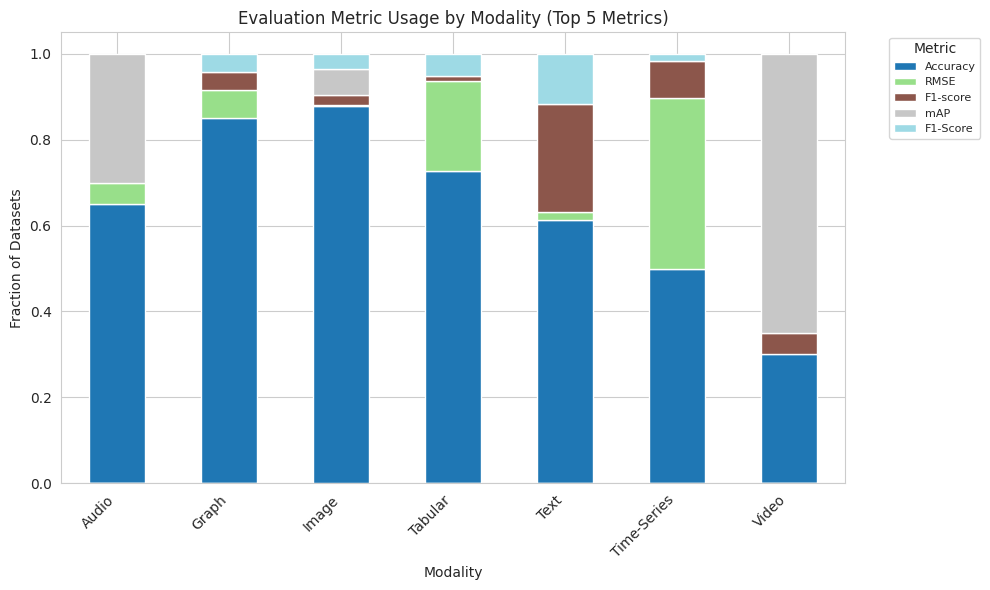

✓ Saved: figure16_metric_usage_bias.png, table5_metric_usage_bias.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metric_df = combined_df[["Modality", "Evaluation Metric"]].dropna().copy()
metric_df["Evaluation Metric"] = metric_df["Evaluation Metric"].astype(str).str.strip()

# কিছু metric একসাথে আছে, যেমন "Accuracy, F1-Score" – first token নেবো
metric_df["MainMetric"] = metric_df["Evaluation Metric"].str.split(",").str[0]
metric_df["MainMetric"] = metric_df["MainMetric"].str.strip()

# modality × metric frequency
metric_cross = pd.crosstab(metric_df["Modality"], metric_df["MainMetric"])

# প্রতিটি modality‑র জন্য top 3 metric দেখার table
top_metrics_rows = []
for m in metric_cross.index:
    row = metric_cross.loc[m].sort_values(ascending=False).head(3)
    top_metrics_rows.append({
        "Modality": m,
        "Top1_Metric": row.index[0] if len(row) > 0 else None,
        "Top1_Count": row.iloc[0] if len(row) > 0 else 0,
        "Top2_Metric": row.index[1] if len(row) > 1 else None,
        "Top2_Count": row.iloc[1] if len(row) > 1 else 0,
        "Top3_Metric": row.index[2] if len(row) > 2 else None,
        "Top3_Count": row.iloc[2] if len(row) > 2 else 0,
    })

metric_summary = pd.DataFrame(top_metrics_rows)
print("Top metrics per modality:")
print(metric_summary)

metric_summary.to_csv("table5_metric_usage_bias.csv", index=False)

# stacked barplot – প্রতি modality‑তে metric distribution (top 5 metrics globally)
global_top_metrics = metric_cross.sum(axis=0).sort_values(ascending=False).head(5).index
metric_cross_top = metric_cross[global_top_metrics]

metric_cross_top.div(metric_cross_top.sum(axis=1), axis=0).plot(
    kind="bar", stacked=True, figsize=(10, 6), colormap="tab20"
)
plt.ylabel("Fraction of Datasets")
plt.xlabel("Modality")
plt.title("Evaluation Metric Usage by Modality (Top 5 Metrics)")
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figure16_metric_usage_bias.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Saved: figure16_metric_usage_bias.png, table5_metric_usage_bias.csv")
